# Unstructured Scraper QA

Generic QA and first-pass EDA for scraper outputs under `data/unstructured/<source>/`. Set `SOURCE` in the setup cell to inspect `gefluegelnews`, `padi_web`, or another source that follows the backend scraper output contract.


## Setup


In [14]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

from collections import Counter
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from IPython.display import Markdown, display


plt.style.use("ggplot")

plt.rcParams.update({"figure.figsize": [14, 7], "text.color": (0.25, 0.25, 0.25)})
pd.options.display.max_columns = 160
pd.options.display.max_rows = 200
pd.options.display.max_colwidth = 140


In [3]:
SOURCE = "gefluegelnews"

EXPECTED_JSONL = {
    "manifest": "manifest.jsonl",
    "articles": "articles.jsonl",
    "parse_errors": "parse_errors.jsonl",
    "disease_articles": "disease_articles.jsonl",
    "disease_reports": "disease_reports.jsonl",
    "disease_reports_embeddings": "disease_reports_embeddings.jsonl",
}


def find_repo_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    for path in [current, *current.parents]:
        if (path / "pyproject.toml").exists() and (path / "data").exists():
            return path
    raise FileNotFoundError(
        "Could not locate repository root with pyproject.toml and data/."
    )


REPO_ROOT = find_repo_root()
DATA_ROOT = REPO_ROOT / "data" / "unstructured"
SOURCE_DIR = DATA_ROOT / SOURCE

if not SOURCE_DIR.exists():
    available = sorted(path.name for path in DATA_ROOT.iterdir() if path.is_dir())
    raise FileNotFoundError(
        f"No scraper output directory found for SOURCE={SOURCE!r}. Available sources: {available}"
    )

SOURCE_DIR

PosixPath('/Volumes/1TB Home SSD/GitHub/_ GitHub generell/GovTech-Tierseuchen/data/unstructured/gefluegelnews')

In [4]:
def read_jsonl(path: Path) -> tuple[pd.DataFrame, pd.DataFrame]:
    rows: list[dict] = []
    errors: list[dict] = []
    if not path.exists():
        return pd.DataFrame(), pd.DataFrame()

    with path.open("r", encoding="utf-8") as handle:
        for line_number, line in enumerate(handle, start=1):
            text = line.strip()
            if not text:
                continue
            try:
                parsed = json.loads(text)
            except json.JSONDecodeError as exc:
                errors.append(
                    {"line_number": line_number, "error": str(exc), "text": text[:300]}
                )
                continue
            if isinstance(parsed, dict):
                rows.append(parsed)
            else:
                rows.append({"value": parsed})

    return pd.json_normalize(rows), pd.DataFrame(errors)


def stable_value(value: object) -> object:
    if isinstance(value, (list, dict)):
        return json.dumps(value, ensure_ascii=False, sort_keys=True)
    return value


def nunique_nested(series: pd.Series) -> int:
    return series.dropna().map(stable_value).nunique(dropna=True)


def schema_summary(data: pd.DataFrame) -> pd.DataFrame:
    if data.empty:
        return pd.DataFrame(columns=["dtype", "missing", "missing_pct", "n_unique"])
    return pd.DataFrame(
        {
            "dtype": data.dtypes.astype(str),
            "missing": data.isna().sum(),
            "missing_pct": data.isna().mean().mul(100).round(1),
            "n_unique": data.apply(nunique_nested),
        }
    ).sort_values(["missing_pct", "n_unique"], ascending=[False, False])


def top_counts(data: pd.DataFrame, column: str, n: int = 15) -> pd.DataFrame:
    if data.empty or column not in data.columns:
        return pd.DataFrame(columns=[column, "records"])
    return (
        data[column]
        .fillna("Missing")
        .value_counts(dropna=False)
        .head(n)
        .rename_axis(column)
        .reset_index(name="records")
    )


def parse_datetime_columns(data: pd.DataFrame, columns: list[str]) -> pd.DataFrame:
    parsed = data.copy()
    for column in columns:
        if column in parsed.columns:
            parsed[column] = pd.to_datetime(parsed[column], errors="coerce", utc=True)
    return parsed


def list_length(value: object) -> int:
    return len(value) if isinstance(value, list) else 0


def flatten_list_values(series: pd.Series) -> list[object]:
    values: list[object] = []
    for item in series.dropna():
        if isinstance(item, list):
            values.extend(item)
        else:
            values.append(item)
    return values


def plot_top_counts(
    data: pd.DataFrame, specs: list[tuple[str, int, str]], cols: int = 2
) -> None:
    available_specs = [spec for spec in specs if spec[0] in data.columns]
    if not available_specs:
        print("No requested columns are available for plotting.")
        return

    rows = -(-len(available_specs) // cols)
    fig, axes = plt.subplots(
        rows, cols, figsize=(7.5 * cols, 4.8 * rows), squeeze=False
    )
    for axis, (column, n, title) in zip(axes.ravel(), available_specs):
        counts = top_counts(data, column, n=n)
        sns.barplot(data=counts, y=column, x="records", ax=axis, color="#4C78A8")
        axis.set_title(title)
        axis.set_xlabel("Records")
        axis.set_ylabel("")
    for axis in axes.ravel()[len(available_specs) :]:
        axis.set_visible(False)
    plt.tight_layout()


def monthly_counts(
    data: pd.DataFrame, date_column: str, label: str = "records"
) -> pd.DataFrame:
    if data.empty or date_column not in data.columns:
        return pd.DataFrame(columns=["month", label])
    return (
        data.dropna(subset=[date_column])
        .assign(
            month=lambda frame: frame[date_column].dt.to_period("M").dt.to_timestamp()
        )
        .groupby("month")
        .size()
        .rename(label)
        .reset_index()
    )

## File Coverage


In [7]:
artifact_rows = []
for name, filename in EXPECTED_JSONL.items():
    path = SOURCE_DIR / filename
    artifact_rows.append(
        {
            "artifact": name,
            "path": path.relative_to(REPO_ROOT),
            "exists": path.exists(),
            "size_mb": round(path.stat().st_size / 1_000_000, 2)
            if path.exists()
            else None,
            "modified_at": pd.to_datetime(path.stat().st_mtime, unit="s")
            if path.exists()
            else pd.NaT,
        }
    )

artifact_status = pd.DataFrame(artifact_rows)
display(artifact_status)

,artifact,path,exists,size_mb,modified_at
0,manifest,data/unstructured/gefluegelnews/manifest.jsonl,True,1.10,2026-05-28 19:28:11.321463108
1,articles,data/unstructured/gefluegelnews/articles.jsonl,True,1.17,2026-05-28 19:28:49.821352005
2,parse_errors,data/unstructured/gefluegelnews/parse_errors.jsonl,True,0.00,2026-05-28 19:28:49.821510792
3,disease_articles,data/unstructured/gefluegelnews/disease_articles.jsonl,True,0.27,2026-05-28 19:29:26.351049662
4,disease_reports,data/unstructured/gefluegelnews/disease_reports.jsonl,True,0.33,2026-05-28 19:29:37.318676472
5,disease_reports_embeddings,data/unstructured/gefluegelnews/disease_reports_embeddings.jsonl,True,0.04,2026-05-28 19:28:11.299923420


In [8]:
frames: dict[str, pd.DataFrame] = {}
jsonl_errors: dict[str, pd.DataFrame] = {}

for name, filename in EXPECTED_JSONL.items():
    frame, errors = read_jsonl(SOURCE_DIR / filename)
    frames[name] = frame
    jsonl_errors[name] = errors

manifest = frames["manifest"]
articles = parse_datetime_columns(
    frames["articles"], ["publication_date", "retrieved_at"]
)
parse_errors = frames["parse_errors"]
disease_articles = frames["disease_articles"]
disease_reports = parse_datetime_columns(
    frames["disease_reports"],
    [
        "source_publication_date",
        "source_retrieved_at",
        "confirmation_date",
        "result_date",
    ],
)
disease_reports_embeddings = parse_datetime_columns(
    frames["disease_reports_embeddings"],
    [
        "source_publication_date",
        "source_retrieved_at",
        "confirmation_date",
        "result_date",
    ],
)

row_counts = pd.DataFrame(
    {
        "artifact": list(frames),
        "rows": [len(frame) for frame in frames.values()],
        "columns": [len(frame.columns) for frame in frames.values()],
        "json_decode_errors": [len(jsonl_errors[name]) for name in frames],
    }
)
display(row_counts)

,artifact,rows,columns,json_decode_errors
0,manifest,3569,13,0
1,articles,298,18,0
2,parse_errors,0,0,0
3,disease_articles,43,24,0
4,disease_reports,43,65,0
5,disease_reports_embeddings,4,71,0


In [9]:
schema_tables = []
for name, frame in frames.items():
    if frame.empty:
        continue
    summary = schema_summary(frame).reset_index(names="column")
    summary.insert(0, "artifact", name)
    schema_tables.append(summary)

schema = (
    pd.concat(schema_tables, ignore_index=True) if schema_tables else pd.DataFrame()
)
display(schema.head(80))

,artifact,column,dtype,missing,missing_pct,n_unique
0,manifest,canonical_url,float64,3569,100.0,0
1,manifest,fetch_error_at,str,3567,99.9,2
2,manifest,fetch_error_message,str,3567,99.9,1
3,manifest,fetch_error_type,str,3567,99.9,1
4,manifest,content_hash,str,3271,91.7,298
5,manifest,fetched_at,str,3271,91.7,298
6,manifest,raw_html_path,str,3271,91.7,298
7,manifest,status_code,float64,3271,91.7,1
8,manifest,source_link,str,0,0.0,3569
9,manifest,discovered_at,str,0,0.0,1


## Pipeline Funnel


,artifact,rows,columns,json_decode_errors
0,manifest,3569,13,0
1,articles,298,18,0
2,parse_errors,0,0,0
3,disease_articles,43,24,0
4,disease_reports,43,65,0
5,disease_reports_embeddings,4,71,0


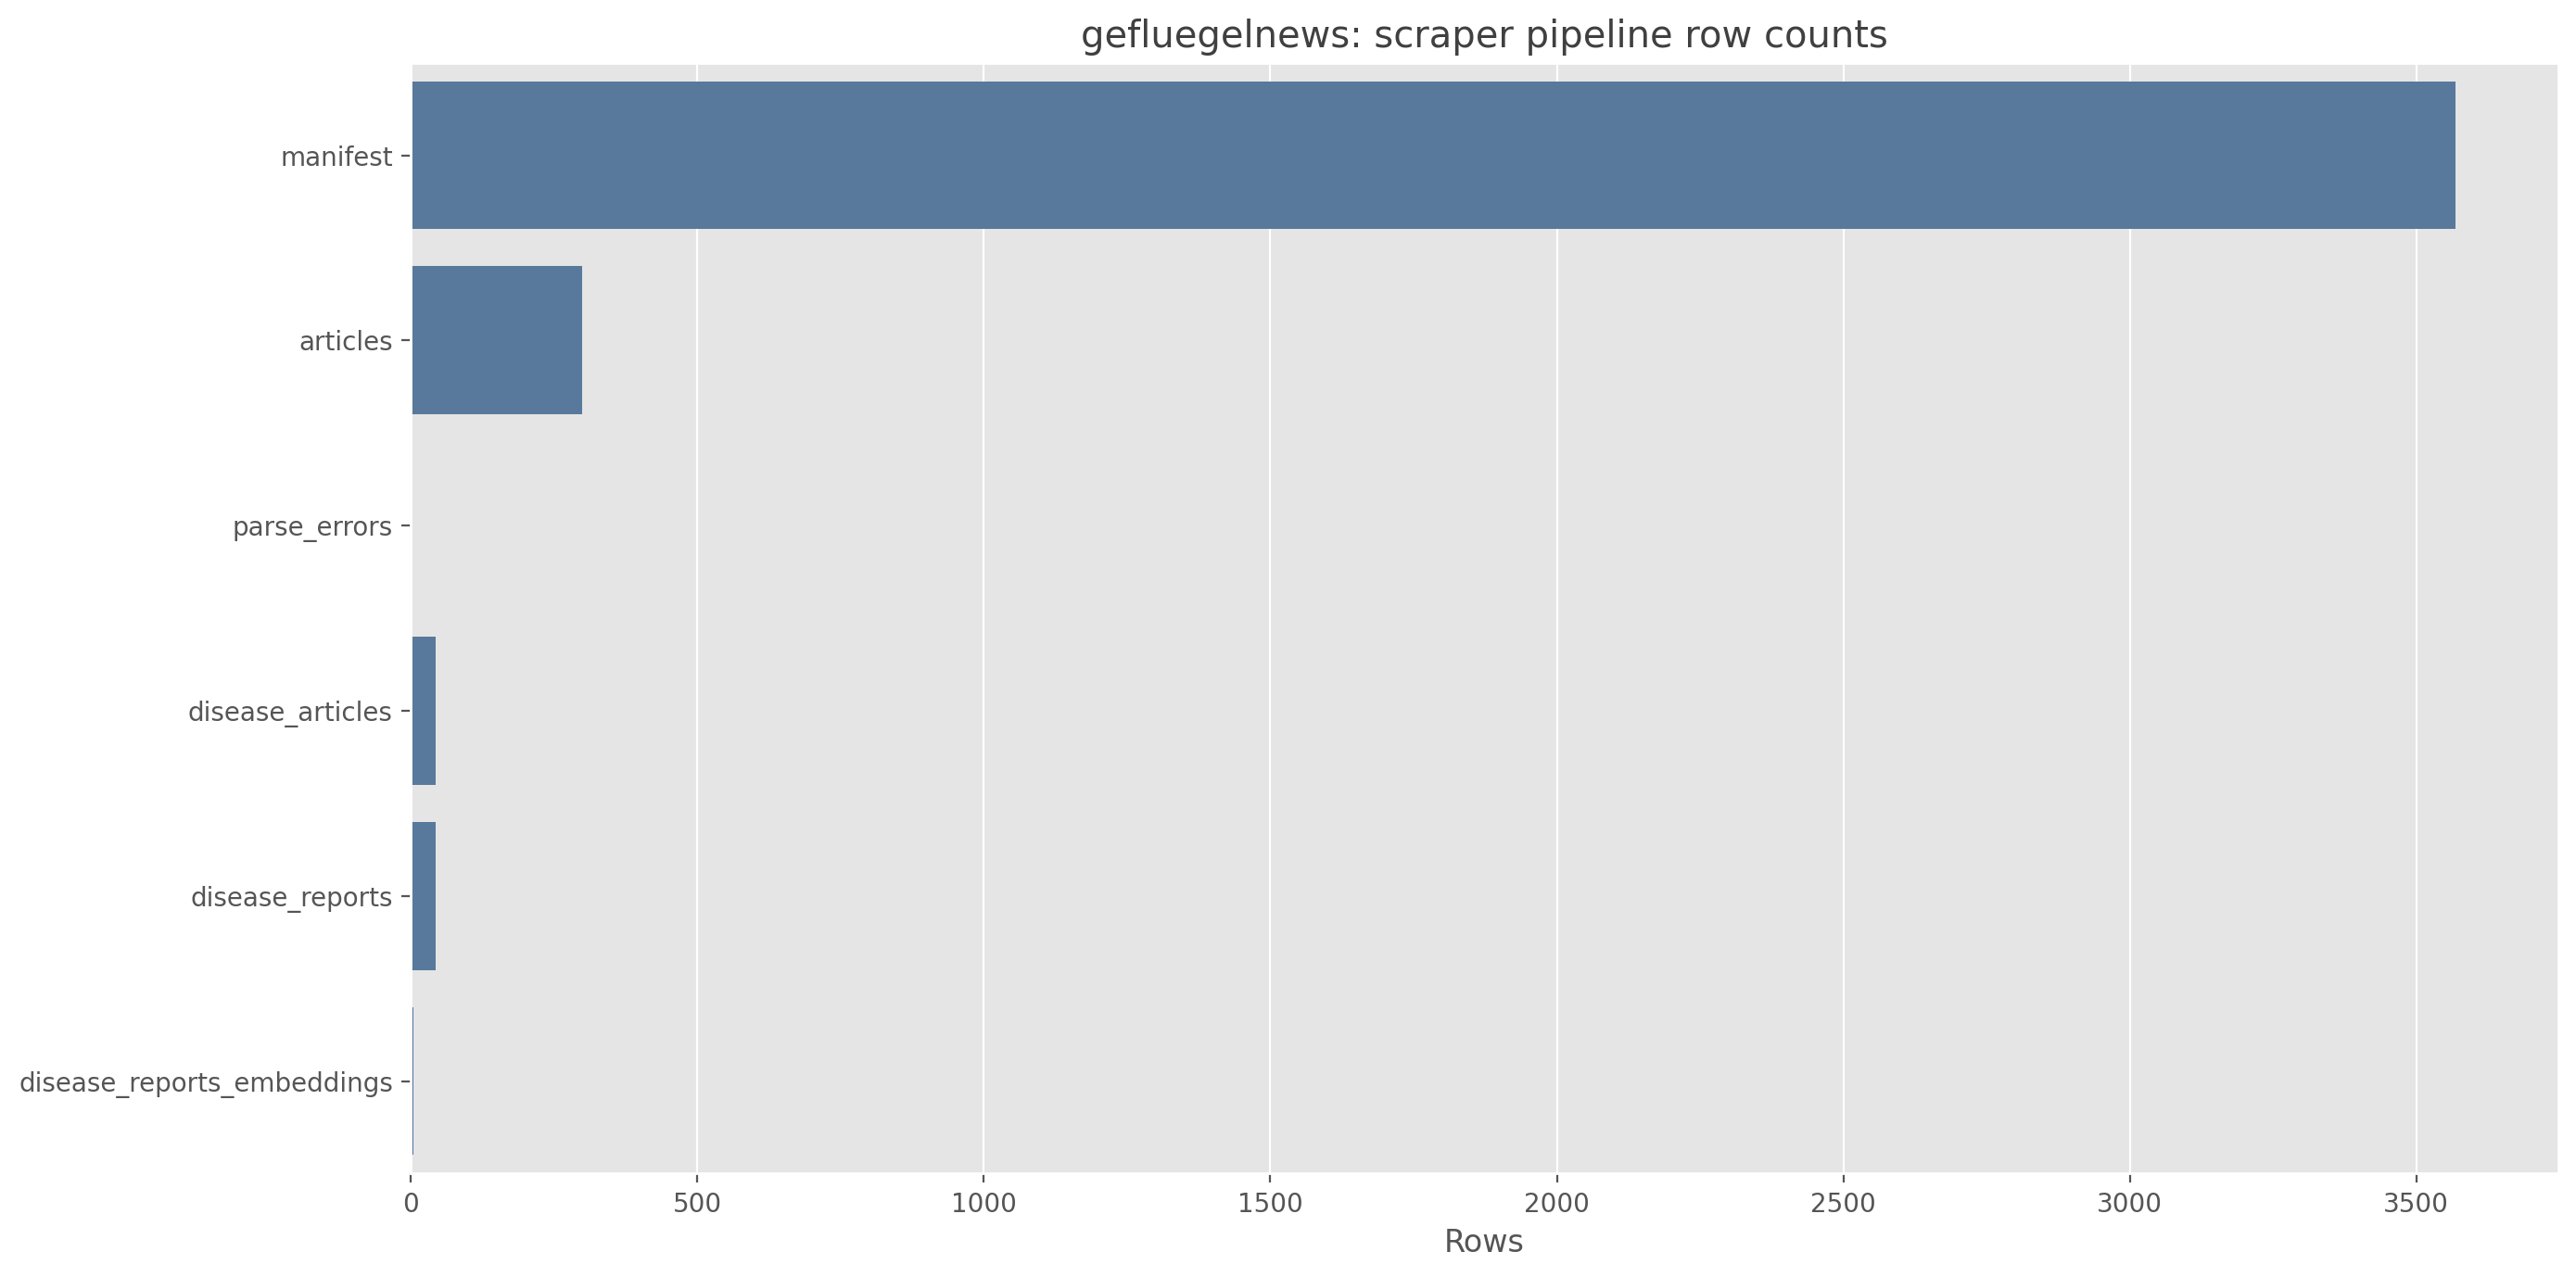

In [10]:
funnel = row_counts[
    row_counts["artifact"].isin(
        [
            "manifest",
            "articles",
            "parse_errors",
            "disease_articles",
            "disease_reports",
            "disease_reports_embeddings",
        ]
    )
].copy()
display(funnel)

axis = sns.barplot(data=funnel, y="artifact", x="rows", color="#4C78A8")
axis.set_title(f"{SOURCE}: scraper pipeline row counts")
axis.set_xlabel("Rows")
axis.set_ylabel("")
plt.tight_layout()

In [11]:
key_checks = []
for name, frame in frames.items():
    for column in [
        "source_link",
        "canonical_url",
        "content_hash",
        "report_id",
        "source_document_id",
    ]:
        if column in frame.columns:
            key_checks.append(
                {
                    "artifact": name,
                    "column": column,
                    "non_null": frame[column].notna().sum(),
                    "unique": frame[column].nunique(dropna=True),
                    "duplicates": frame[column].dropna().duplicated().sum(),
                }
            )

display(pd.DataFrame(key_checks))

,artifact,column,non_null,unique,duplicates
0,manifest,source_link,3569,3569,0
1,manifest,canonical_url,0,0,0
2,manifest,content_hash,298,298,0
3,articles,source_link,298,298,0
4,articles,canonical_url,298,298,0
5,articles,content_hash,298,298,0
6,disease_reports,source_link,43,43,0
7,disease_reports,content_hash,43,43,0
8,disease_reports,report_id,43,43,0
9,disease_reports,source_document_id,43,43,0


In [12]:
decode_error_tables = []
for name, errors in jsonl_errors.items():
    if errors.empty:
        continue
    with_name = errors.copy()
    with_name.insert(0, "artifact", name)
    decode_error_tables.append(with_name)

decode_errors = (
    pd.concat(decode_error_tables, ignore_index=True)
    if decode_error_tables
    else pd.DataFrame()
)
display(decode_errors.head(20))

""


## Article EDA


In [7]:
articles, article_jsonl_errors = read_jsonl(SOURCE_DIR / EXPECTED_JSONL["articles"])
articles = parse_datetime_columns(articles, ["publication_date", "retrieved_at"])

print(f"Loaded {len(articles):,} articles with {len(articles.columns):,} columns.")
display(articles.head().T)

Loaded 298 articles with 18 columns.


,0,1,2,3,4
author,"Text: ""Spaß bei der Arbeit, Kreativ sein und gemeinsam ein schönes Ziel erreichen!"" Mehr von diesem Autor",Seppenhagen,Seppenhagen,Geflügelnews,"Text: ""Spaß bei der Arbeit, Kreativ sein und gemeinsam ein schönes Ziel erreichen!"" Mehr von diesem Autor"
canonical_url,https://www.gefluegelnews.de/article/10-jahre-otz-jubilaum-auf-den-okofeldtagen-gefeiert,https://www.gefluegelnews.de/article/100-jahre-hof-seppenhagen,https://www.gefluegelnews.de/article/100-jahre-hof-seppenhagen-qualitat-aus-tradition,https://www.gefluegelnews.de/article/100000-legehennen-wegen-newcastle-krankheit-gekeult,https://www.gefluegelnews.de/article/10000000-geschlupfte-kuken-aus-der-ab-ovo-bruterei-in-ahlen
category,Deutschland,Masthuhn,Deutschland,Biosicherheit,Brüterei
content_hash,d91d1e93d77f4a31e754b137533f41322b0d873ead295a8f4771fe35faebf261,652f509ed39f1cf79d0631eaafdc881f97905d7d7c0bd613bdca49a875781a24,04b2a5645e0bda0d59a9c2346a61ca8a891a09d7cebbe1479597918664ae056d,525a0de4581c7f69912f7b7166af6862d887aa4de09a6acef4bb47e4bb5328b3,0bf1c457bc9eb0c3320ffd1e37d09441de329e6fd65655c1bdc889b3814377a3
description,Die ÖTZ feiert ihr 10-jähriges Jubiläum auf den Ökofeldtagen 2025. Inga Günther-Bender blickt in die Zukunft der Öko-Geflügelzucht.,"In Ahlen im schönen Münsterland liegt der Hof „Seppenhagen“. Er ist seit vielen Generationen Heimat, Wohnort und Arbeitsplatz der Famili...",Die Familien Wolter führen den Hof Seppenhagen am Ahlener Prozessionsweg nunmehr erfolgreich in der 4. Generation und widmen sich seit ü...,Nach dem Ausbruch der Newcastle-Krankheit im Landkreis Erding haben die Behörden 100.000 Legehennen keulen lassen. Schutz- und Überwachu...,Das 10 Millionste Küken ist in der ab ovo Brüterei in Ahlen geschlüpft. Wir durften bei diesem besonderen Anlass dabei sein und haben di...
fulltext,# 10 Jahre ÖTZ – Jubiläum auf den Ökofeldtagen gefeiert\n\n**Die Ökologische Tierzucht gGmbH (ÖTZ) feiert 2025 ihr zehnjähriges Bestehen...,# 100 Jahre Hof „Seppenhagen“\n\n**Erfahrung aus vier Generationen**\n\nSeit nunmehr vier Generationen besteht unser Hof stolz und bestä...,# 100 Jahre Hof Seppenhagen - Qualität aus Tradition\n\n**Die Familien Wolter führen den Hof Seppenhagen am Ahlener Prozessionsweg nunme...,# 100.000 Legehennen wegen Newcastle-Krankheit gekeult\n\n**Nach dem Nachweis der Newcastle-Krankheit auf einem großen Legehennenbetrieb...,# 10.000.000 geschlüpfte Küken aus der ab ovo Brüterei in Ahlen\n\n**Das 10 Millionste Küken ist in der ab ovo Brüterei in Ahlen geschlü...
image_credit,Dieter Theyssen,Seppenhagen,Seppenhagen,Cordula Möbius,Dieter Theyssen
image_url,https://www.gefluegelnews.de/storage/Va1FExGi9Dd9xGyJmoh2q021osDGUl6CDFlOXMZc_470x264.jpg,https://www.gefluegelnews.de/storage/RKCTO3Ufk9KPrifP3x7lazx3xBi0w6wHjZ9G1CGv_470x264.jpg,https://www.gefluegelnews.de/storage/twucWh75eGD13nMLALcVuRhZvnwhUWf6HnfFRJb6_470x264.jpg,https://www.gefluegelnews.de/storage/aj1kRGD8d7eSueWkJeEwCo5gtVOqqxkTHykR9jiv_470x264.jpg,https://www.gefluegelnews.de/storage/cwum2mGViM1Br4dKcJg61RbwI4MfOf7n4Usssetc_470x264.jpg
keywords,"[Landwirtschaft, Landwirt, Landwirtin, Tierhaltung, Ökolandbau, Agrar, Agrarpolitik, Hof, Stall, Bio, Biolandbau, nachhaltige Landwirtsc...","[Seppenhagen, Junghennen, Masthühner]","[Seppenhagen, Hoffest, Jubiläum, Geflügelzucht]",[Newcastle-Krankheit Landkreis Erding 100.000 Legehennen Keulung Geflügelpest APMV-1 Schutzgebiet Überwachungszone Landratsamt Erding La...,"[Brüterei, abovo, Biobrüterei, JUbiläum]"
partner_content,None,None,None,None,None


In [18]:
display(Markdown(articles.sample(1).fulltext.values[0]))

# Bauerndemo: Lindner hält an Sparplänen fest

**Die Bundesregierung wird keine weiteren Abstriche an ihren Sparplänen zu Lasten der Landwirtschaft machen. Bundesfinanzminister Christian Lindner bekräftigte auf der Großkundgebung mit rund 30.000 Teilnehmern am Montag (15.1.) vor dem Brandenburger Tor in Berlin den Beschluss, die Agrardieselvergünstigung in drei Jahresschritten abzubauen. Er begründete das mit den dringend notwendigen Einsparungen, zu denen auch die Bauern einen Beitrag leisten müssten.**

Der FDP-Politiker bot zugleich an, den Betrieben entgegenzukommen und Belastungen an anderer Stelle zu reduzieren. Konkret stellte Lindner in Aussicht, die Tarifglättung bei der Einkommensteuer nun doch zu entfristen und die Einführung einer steuerfreien Risikoausgleichsrücklage zu prüfen. Offen zeigte sich der Minister für die Forderungen nach Bürokratieabbau. Er sprach sich dafür aus, planbare Perspektiven für den Einsatz von Pflanzenschutzmitteln zu schaffen, Auflagen für die Tierhaltung zu durchforsten, an Biokraftstoffen aus Anbaubiomasse festzuhalten und auf die obligatorische Stilllegung von 4% im Rahmen der Gemeinsamen Agrarpolitik (GAP) zu verzichten.

## Fauler Kompromiss

Der Präsident des Deutschen Bauernverbandes (DBV), Joachim Rukwied, hatte zuvor erneut gefordert, die Streichung der Agrardieselbeihilfe vollständig zurückzunehmen. Die entschärften Sparpläne der Regierung bezeichnete Rukwied einmal mehr als „faulen Kompromiss“. Nach der erfolgreichen Großdemonstration musste DBV-Präsident Joachim Rukwied jedoch mit Enttäuschung zur Kenntnis nehmen, dass es bei den anschließenden Gesprächen der Landwirtschaft mit den Spitzen der Ampelfraktionen kein Ergebnis bei der Diskussion um den Agrardiesel gab. „Nur eine Lösung beim Agrardiesel wird die Traktoren von der Straße bekommen. Wir hoffen sehr, dass noch Vernunft bei der Ampel-Koalition einkehrt und man uns in dieser Frage bei der Haushaltbereinigungssitzung entgegenkommt. Der Ball liegt im Spielfeld der Koalitionäre", so Rukwied“

## Etwa 10.000 Teilnehmer

Schätzungen der Veranstalter zufolge lag die Zahl der Traktoren und Transportfahrzeuge in Berlin bei rund 10.000. Neben dem Transportgewerbe hatten sich auch Handwerkerorganisationen beteiligt, beispielsweise das Bäckerhandwerk. Rukwied bezeichnete die bislang größte Demonstration im Rahmen der Proteste gegen die Sparpläne als weiteres wichtiges Signal an die Berliner Politik, endlich einen Kurswechsel vorzunehmen. Es gehe letzten Endes um die Sicherstellung der Versorgung mit heimischen Lebensmitteln.

In [13]:
if articles.empty:
    print("No articles.jsonl rows loaded.")
else:
    article_dates = pd.DataFrame(
        {
            "date_column": [
                column
                for column in ["publication_date", "retrieved_at"]
                if column in articles.columns
            ],
            "min_date": [
                articles[column].min()
                for column in ["publication_date", "retrieved_at"]
                if column in articles.columns
            ],
            "max_date": [
                articles[column].max()
                for column in ["publication_date", "retrieved_at"]
                if column in articles.columns
            ],
            "missing": [
                articles[column].isna().sum()
                for column in ["publication_date", "retrieved_at"]
                if column in articles.columns
            ],
        }
    )
    display(article_dates)
    display(schema_summary(articles).head(40))

,date_column,min_date,max_date,missing
0,publication_date,2022-02-15 00:00:00+00:00,2026-05-27 00:00:00+00:00,0
1,retrieved_at,2026-05-28 17:54:15.543130+00:00,2026-05-28 17:58:52.052356+00:00,0


,dtype,missing,missing_pct,n_unique
partner_content,object,298,100.0,0
source_attribution,str,180,60.4,28
author,str,12,4.0,73
image_credit,str,4,1.3,135
canonical_url,str,0,0.0,298
content_hash,str,0,0.0,298
fulltext,str,0,0.0,298
image_url,str,0,0.0,298
raw_html_path,str,0,0.0,298
retrieved_at,"datetime64[us, UTC]",0,0.0,298


/var/folders/mb/b3m4vb7919z0c5vsfg_t8f2h0000gp/T/ipykernel_6826/2057422915.py:99: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout()


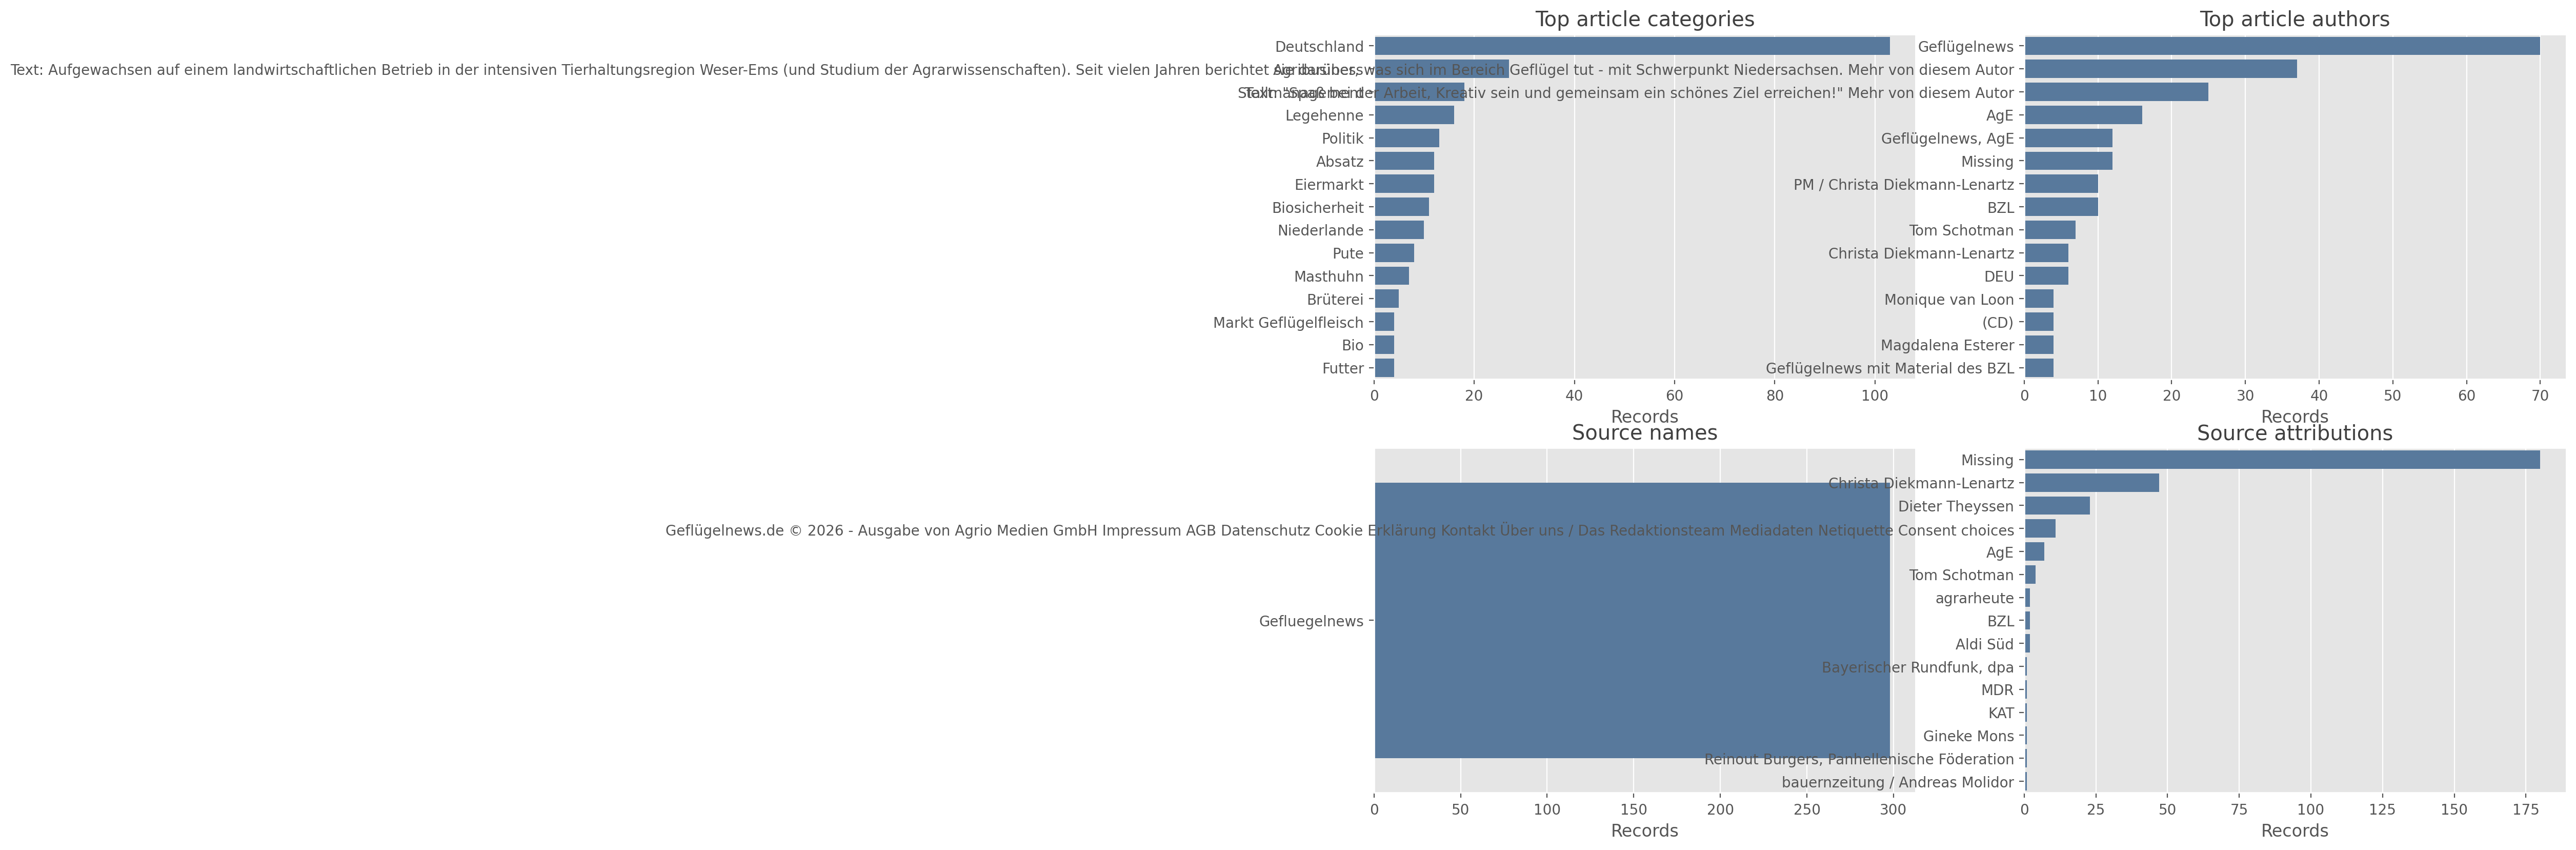

In [12]:
if not articles.empty:
    plot_top_counts(
        articles,
        [
            ("category", 15, "Top article categories"),
            ("author", 15, "Top article authors"),
            ("source_name", 10, "Source names"),
            ("source_attribution", 15, "Source attributions"),
        ],
    )

/var/folders/mb/b3m4vb7919z0c5vsfg_t8f2h0000gp/T/ipykernel_6826/2057422915.py:107: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  .assign(month=lambda frame: frame[date_column].dt.to_period("M").dt.to_timestamp())


,month,articles
27,2024-06-01,6
28,2024-07-01,10
29,2024-08-01,7
30,2024-09-01,13
31,2024-10-01,6
32,2024-11-01,4
33,2024-12-01,6
34,2025-01-01,3
35,2025-02-01,5
36,2025-03-01,6


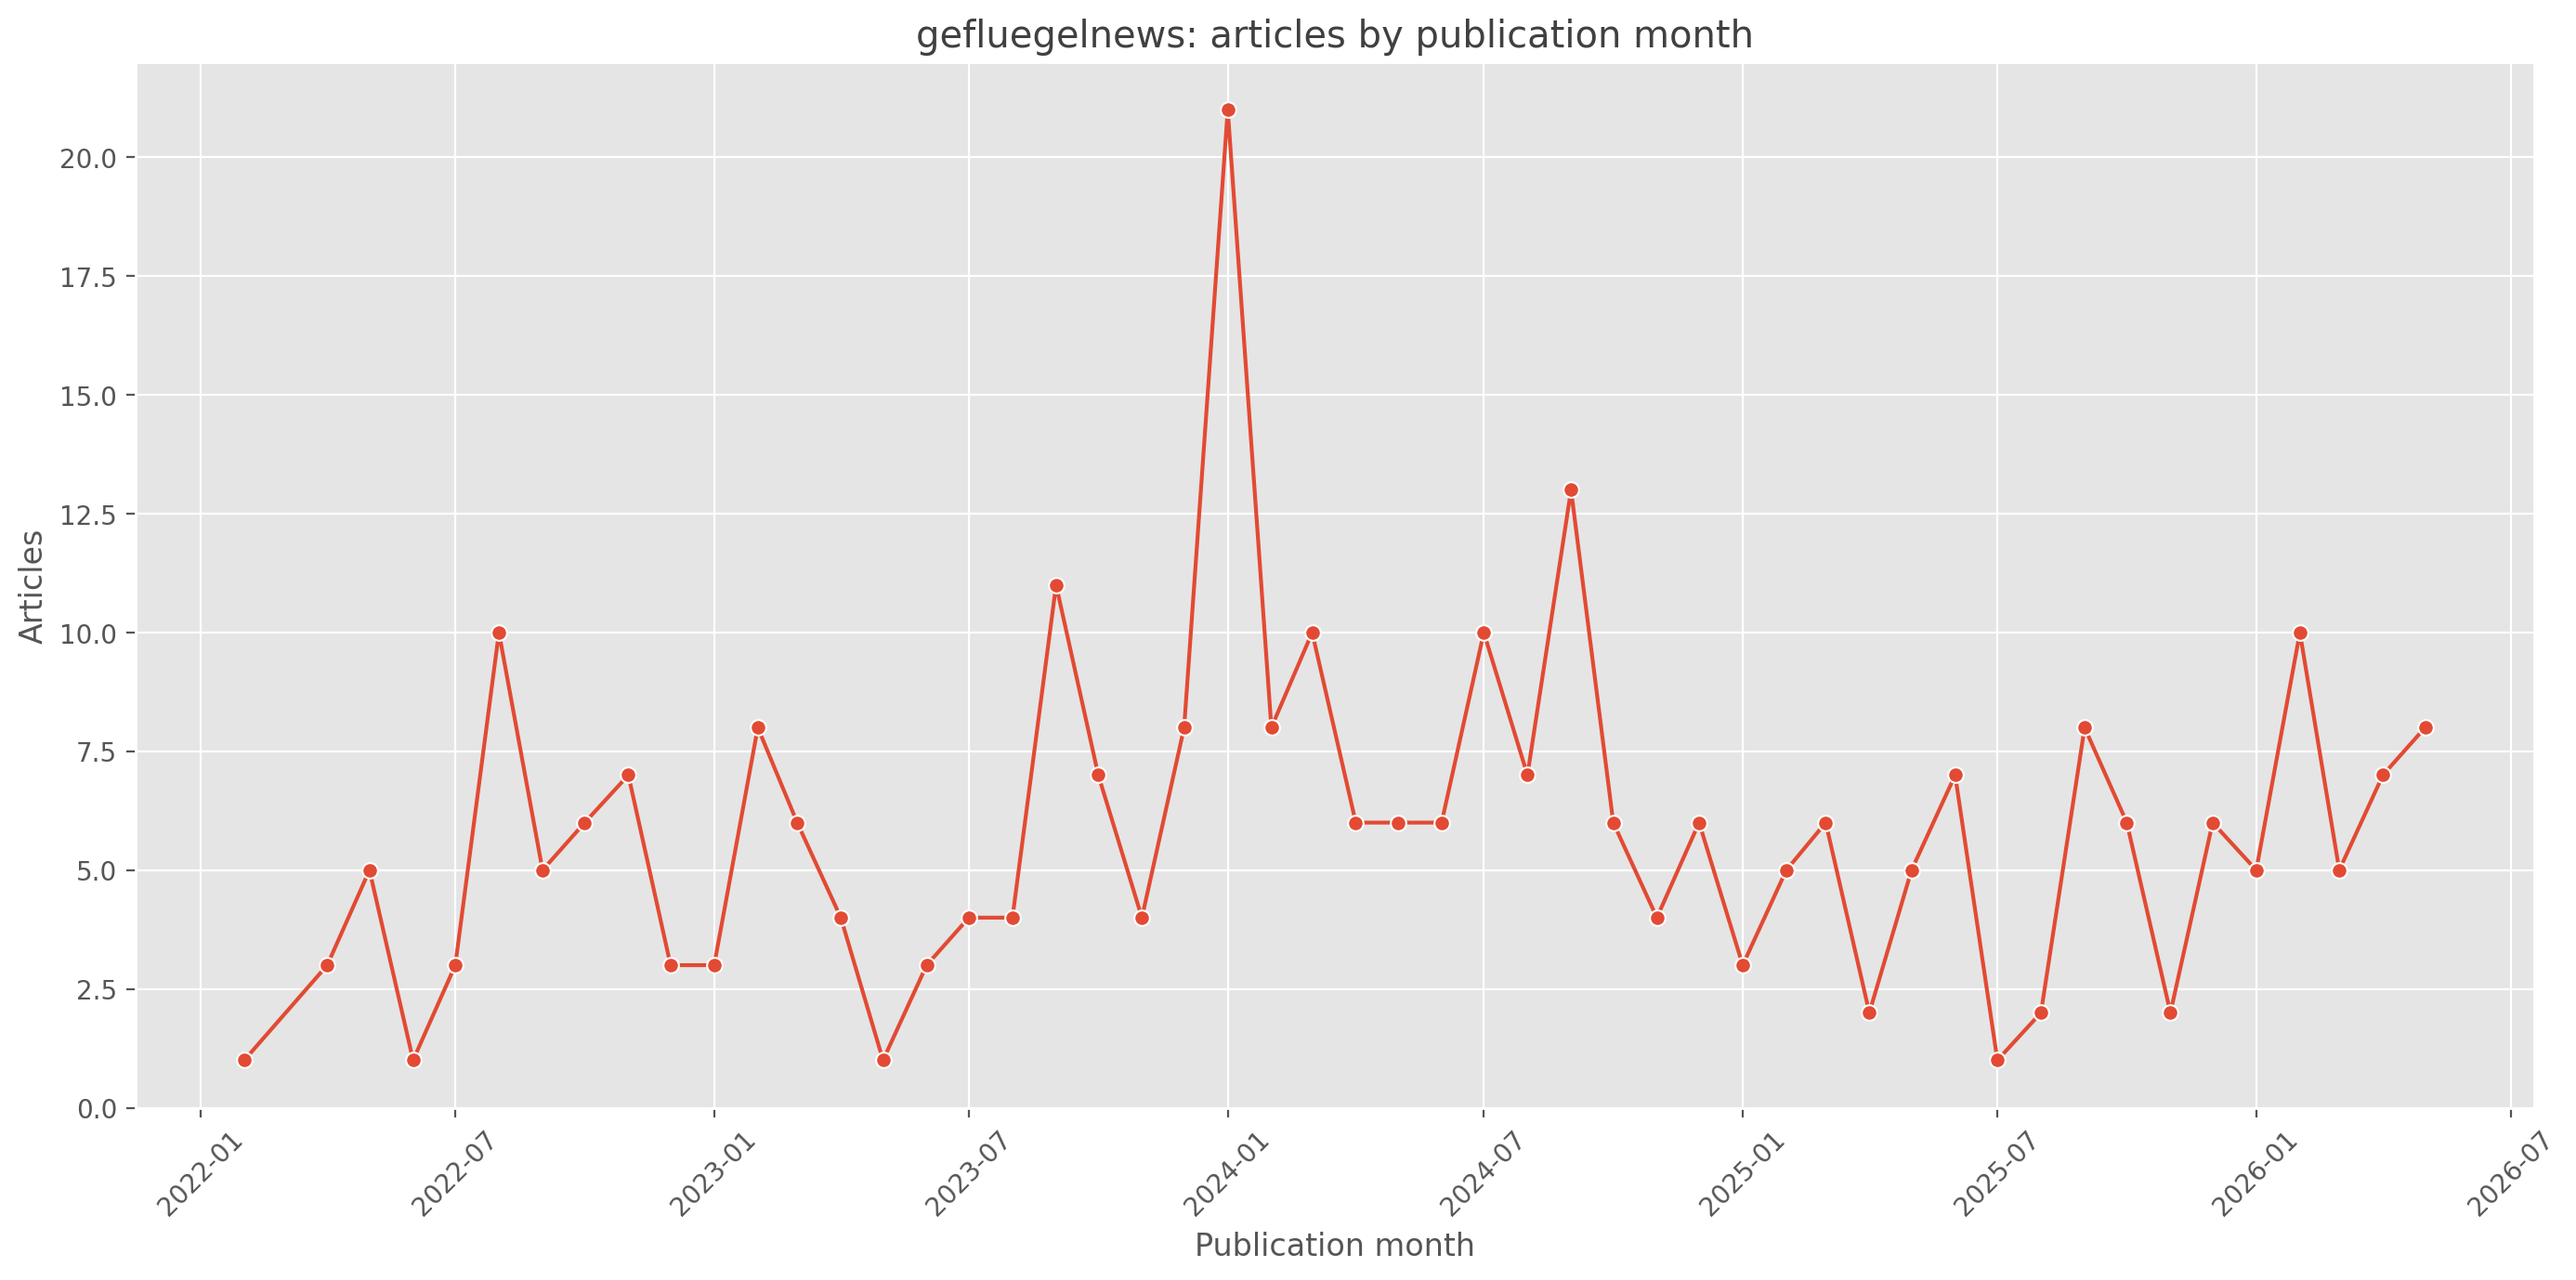

In [13]:
if not articles.empty and "publication_date" in articles.columns:
    article_months = monthly_counts(articles, "publication_date", label="articles")
    display(article_months.tail(24))
    axis = sns.lineplot(data=article_months, x="month", y="articles", marker="o")
    axis.set_title(f"{SOURCE}: articles by publication month")
    axis.set_xlabel("Publication month")
    axis.set_ylabel("Articles")
    plt.xticks(rotation=45)
    plt.tight_layout()

,title,publication_date,fulltext_chars,fulltext_words
272,Bauernproteste: Auch die Geflügelbranche fährt mit,2024-01-08 00:00:00+00:00,246,30
130,Aktuelle Situation an den Eier- und Geflügelmärkten,2022-05-30 00:00:00+00:00,303,43
75,Agrar Unternehmertage Münster 2024,2024-02-07 00:00:00+00:00,324,45
257,Autarke Energieversorgung im Stall am Beispiel von Big Dutchman,2022-11-21 00:00:00+00:00,337,48
252,Auswirkungen eines Blackouts auf die Nutztierhaltung bei Betrieben mit Stallhaltung,2023-03-24 00:00:00+00:00,384,50
296,Beleuchtung im Stall-Infomagazin,2022-11-23 00:00:00+00:00,378,54
124,"AirMaster Flex 140C | Hohe Luftleistung, energiesparend und korrosionsbeständig",2023-04-08 00:00:00+00:00,454,56
72,AGRAR Unternehmertage 2026 in Münster: So präsentiert sich die Geflügelbranche auf der Messe,2026-02-04 00:00:00+00:00,369,56
4,10.000.000 geschlüpfte Küken aus der ab ovo Brüterei in Ahlen,2024-10-25 00:00:00+00:00,389,58
152,Alternative Proteinversorgung dank Schwarzer Soldatenfliege,2022-11-29 00:00:00+00:00,428,58


,title,publication_date,fulltext_chars,fulltext_words
24,30 Jahre Bioland-Geflügeltagung: Was die Ökobranche gelernt hat – und welche Probleme bleiben,2026-03-15 00:00:00+00:00,7652,1014
192,"„Auf dem Eiermarkt zieht die Industrie den Karren aus dem Dreck""",2022-10-05 00:00:00+00:00,6941,1011
295,Bekämpfung Geflügelpest: Bisheriges System nicht mehr bezahlbar?,2023-02-14 00:00:00+00:00,6722,936
8,13. Osnabrücker Geflügelsymposium: Diskussionen um Impfung und Keulung,2026-05-26 00:00:00+00:00,6850,925
123,AI-Monitoring in Putenbeständen erfolgreich etabliert,2022-08-25 00:00:00+00:00,7106,923
53,8600 Tiere gekeult: Wie die Vogelgrippe einen Hof in Brandenburg an den Rand der Belastbarkeit brachte,2026-02-08 00:00:00+00:00,6006,888
25,30 Jahre KAT: Kontrollsystem setzt Maßstäbe für Transparenz in der Lebensmittelbranche,2025-05-21 00:00:00+00:00,6759,856
132,Aktuelles Interview: Geflügelhalter in Niedersachsen - Fluch oder Segen?,2025-11-21 00:00:00+00:00,6165,841
268,"Bald für alle: Oben Solarstrom, unten Legehennen",2023-09-21 00:00:00+00:00,5818,800
147,"„Alles, was wir tun, muss etwas bringen“",2023-08-07 00:00:00+00:00,5494,789


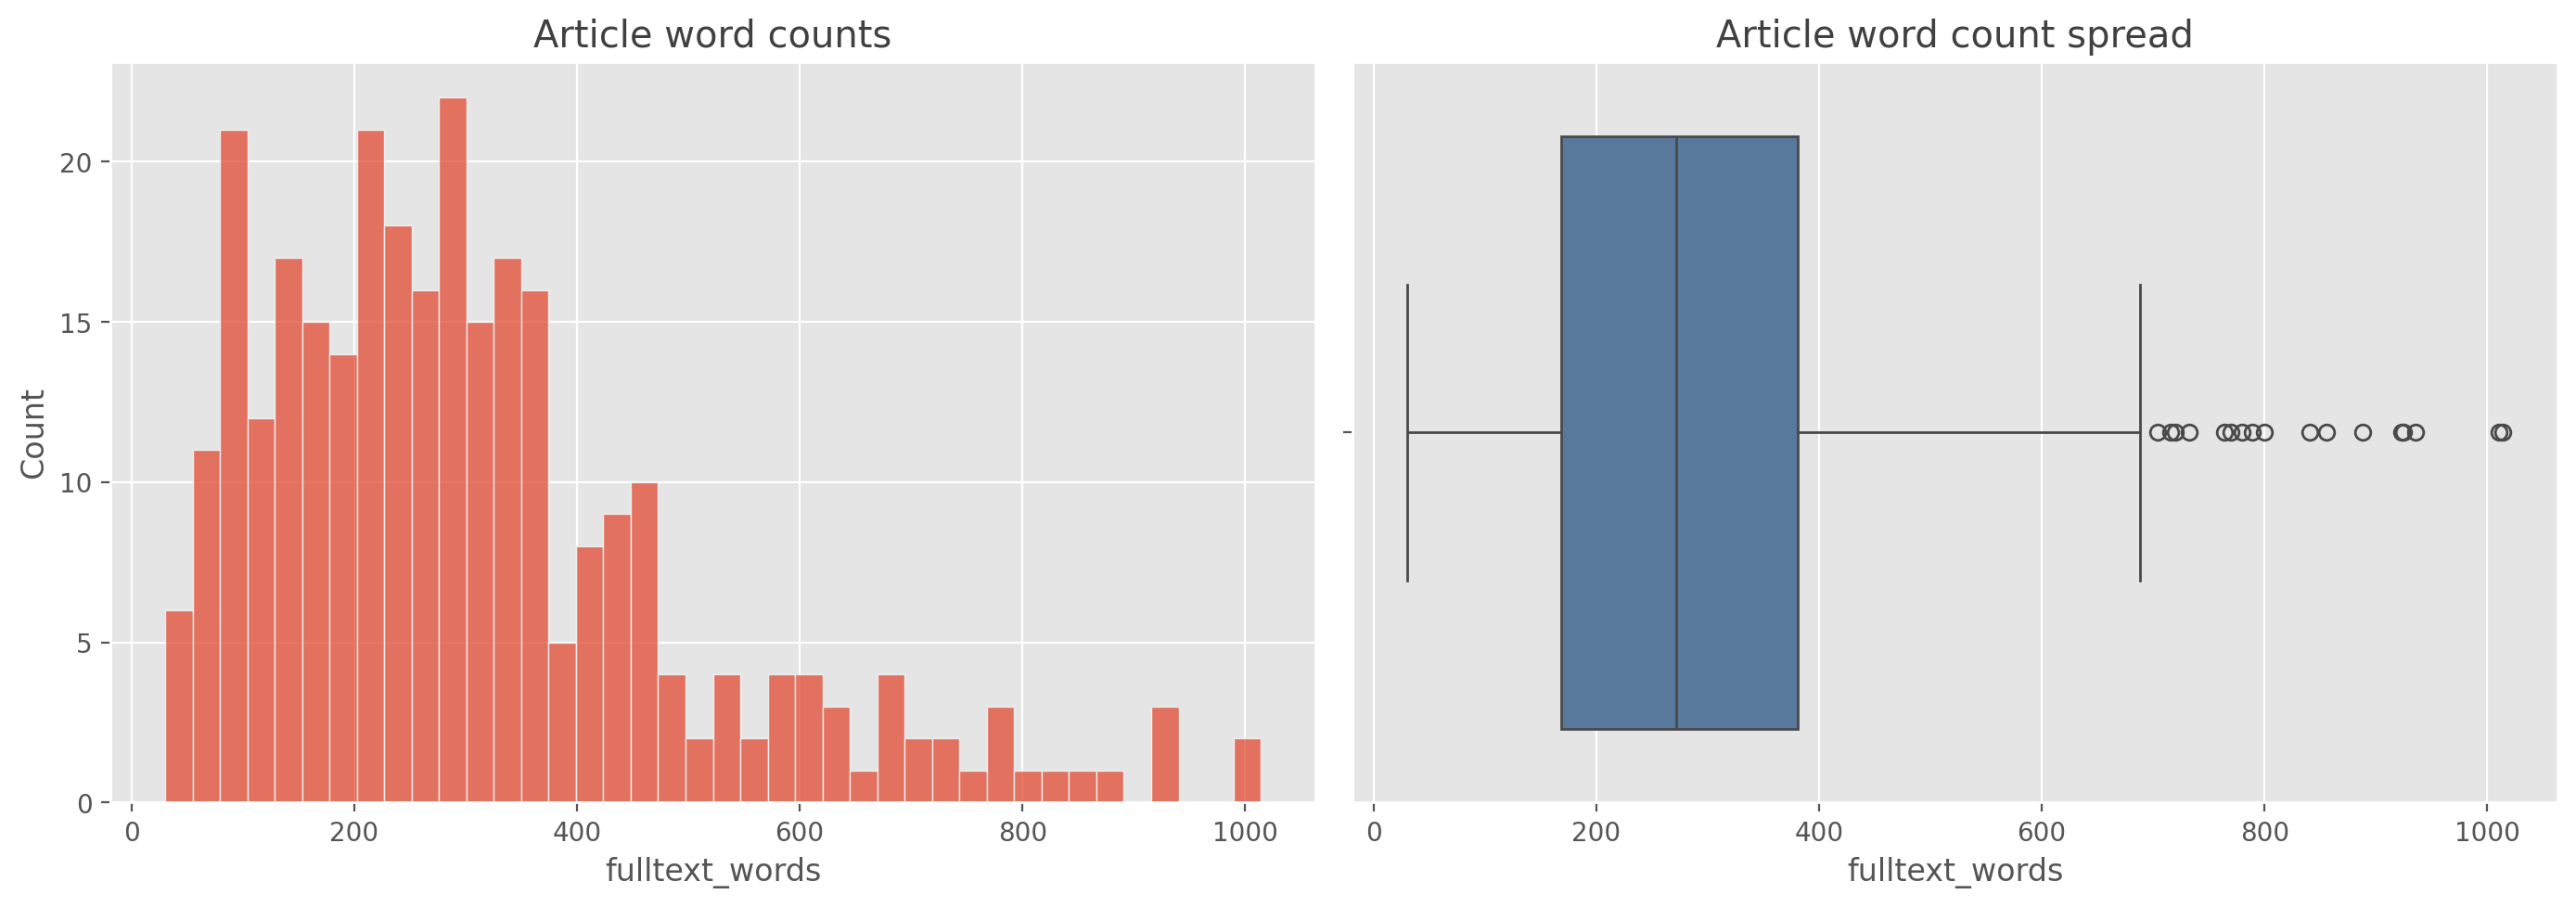

In [14]:
if not articles.empty and "fulltext" in articles.columns:
    article_text = articles.assign(
        fulltext_chars=articles["fulltext"].fillna("").str.len(),
        fulltext_words=articles["fulltext"].fillna("").str.split().str.len(),
    )
    display(
        article_text[["title", "publication_date", "fulltext_chars", "fulltext_words"]]
        .sort_values("fulltext_words")
        .head(10)
    )
    display(
        article_text[["title", "publication_date", "fulltext_chars", "fulltext_words"]]
        .sort_values("fulltext_words", ascending=False)
        .head(10)
    )

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    sns.histplot(data=article_text, x="fulltext_words", bins=40, ax=axes[0])
    axes[0].set_title("Article word counts")
    sns.boxplot(data=article_text, x="fulltext_words", ax=axes[1], color="#4C78A8")
    axes[1].set_title("Article word count spread")
    plt.tight_layout()

,keyword,articles
0,Landwirtschaft,29
1,Tierwohl,22
2,Tierhaltung,20
3,Geflügel,20
4,Legehennen,18
5,Geflügelhaltung,18
6,Agrardiesel,18
7,Vogelgrippe,17
8,Eier,16
9,BZL,14


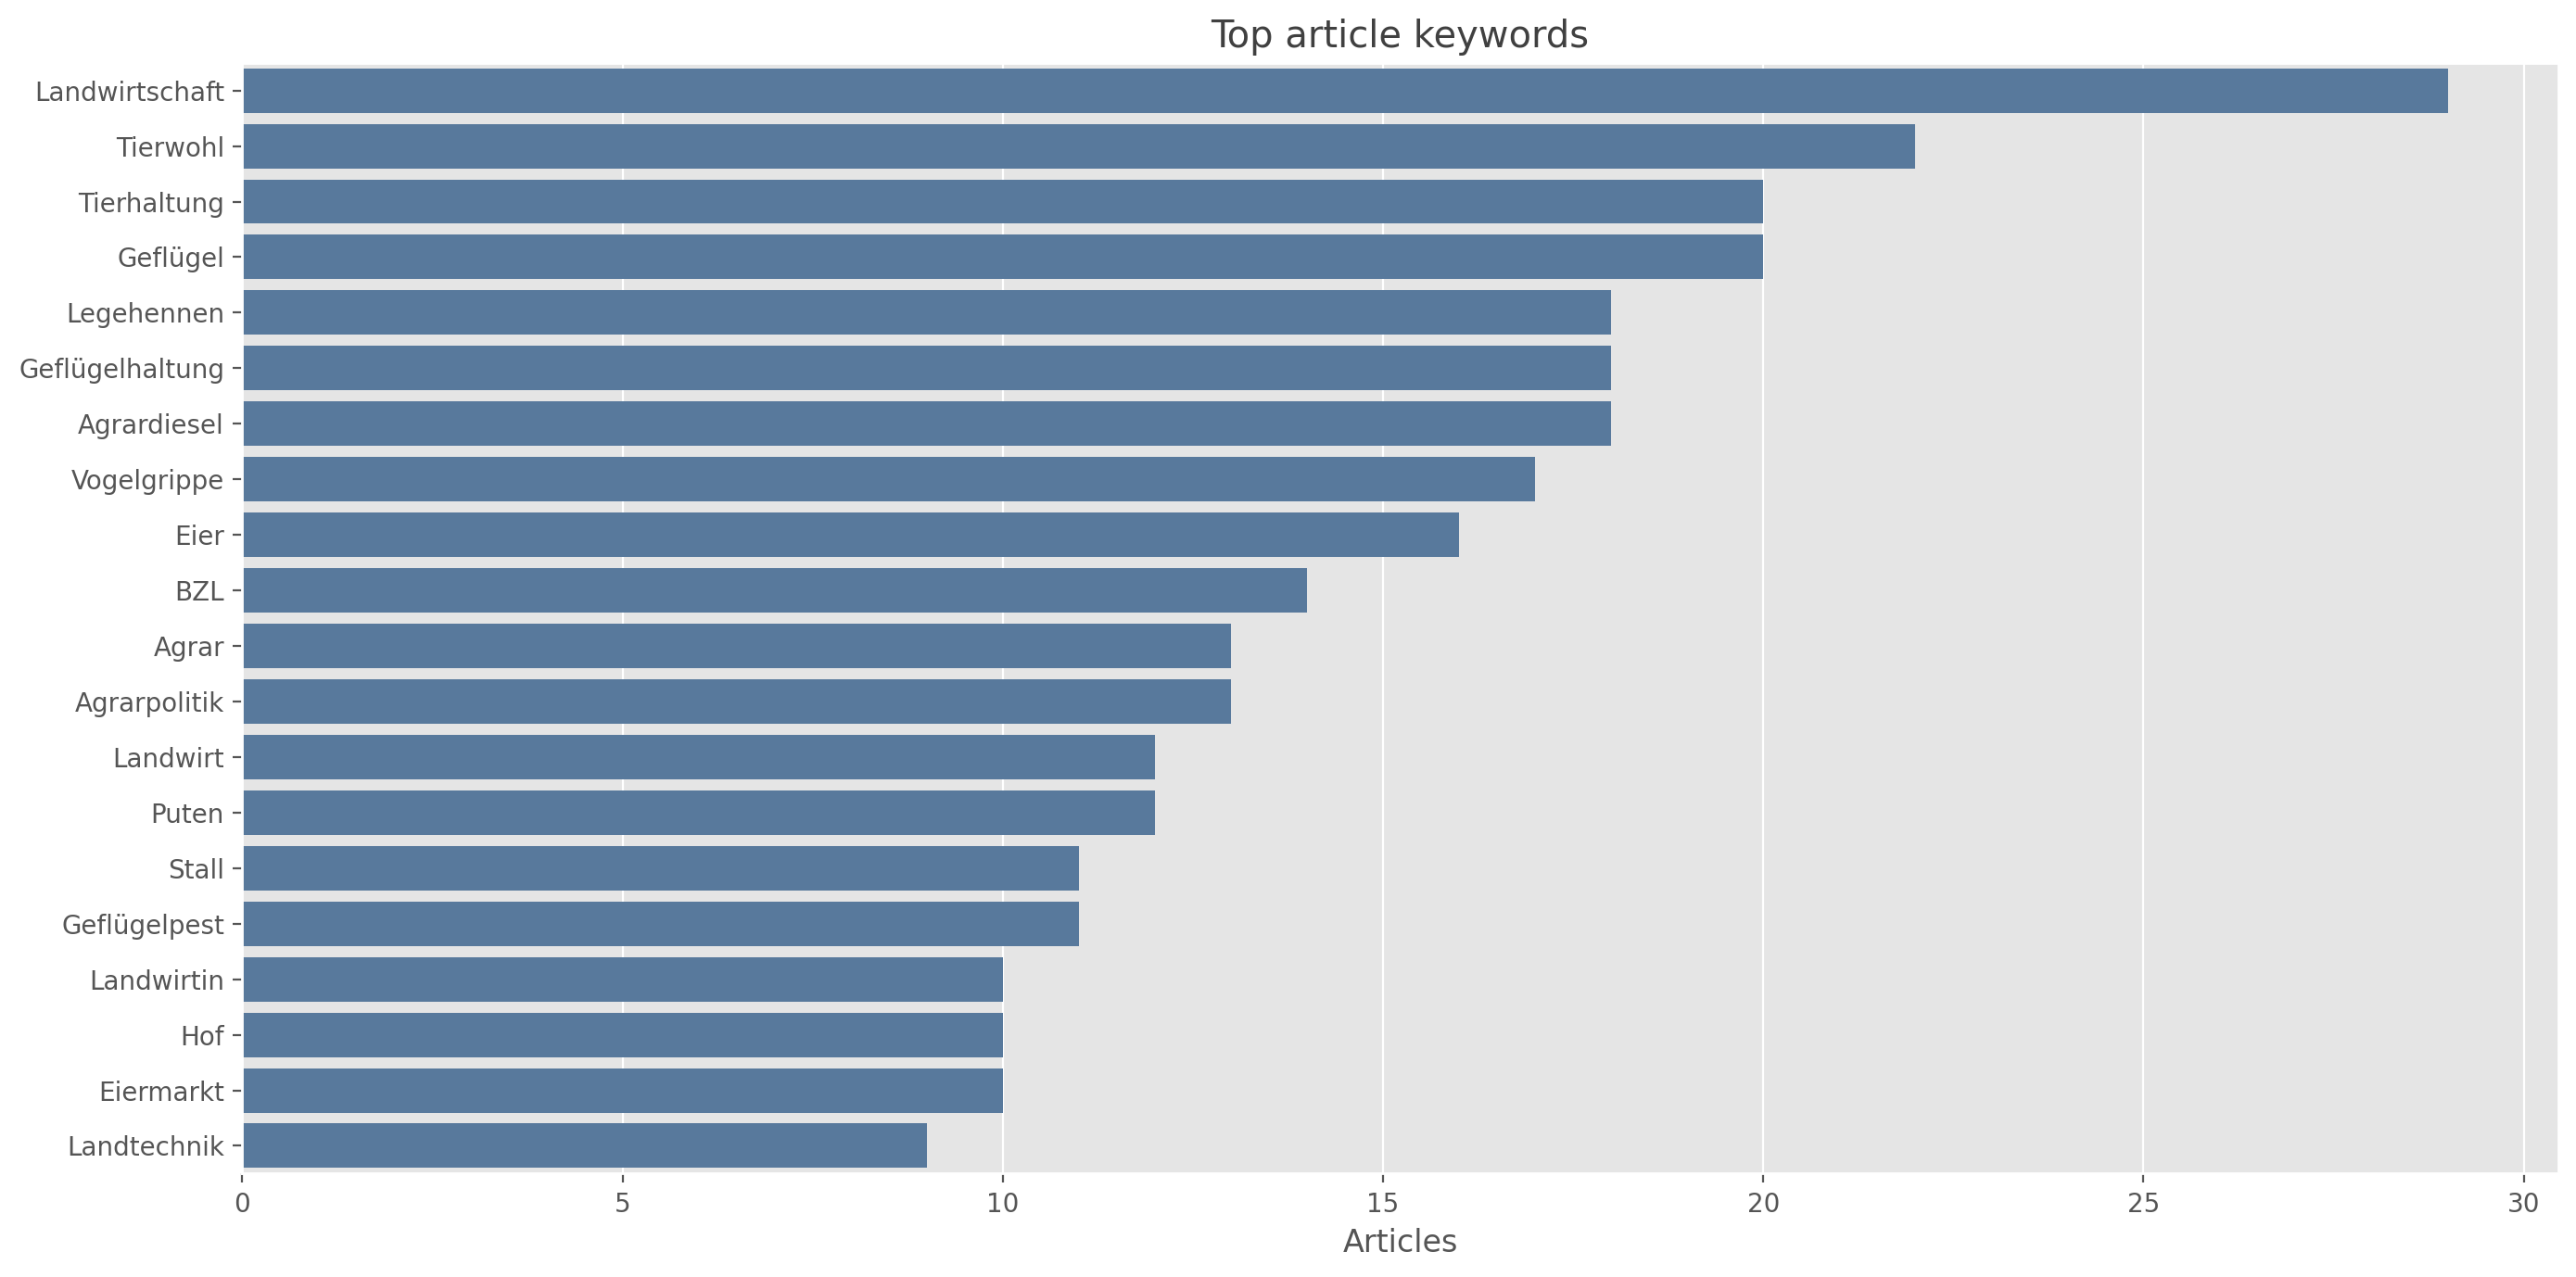

In [15]:
if not articles.empty and "keywords" in articles.columns:
    keyword_counts = Counter(
        str(value).strip()
        for value in flatten_list_values(articles["keywords"])
        if str(value).strip()
    )
    top_keywords = pd.DataFrame(
        keyword_counts.most_common(40), columns=["keyword", "articles"]
    )
    display(top_keywords.head(25))
    if not top_keywords.empty:
        axis = sns.barplot(
            data=top_keywords.head(20), y="keyword", x="articles", color="#4C78A8"
        )
        axis.set_title("Top article keywords")
        axis.set_xlabel("Articles")
        axis.set_ylabel("")
        plt.tight_layout()

## Disease Filter QA


,dtype,missing,missing_pct,n_unique
article.partner_content,object,43,100.0,0
article.source_attribution,str,21,48.8,13
article.author,str,3,7.0,16
article.image_credit,str,1,2.3,32
article.canonical_url,str,0,0.0,43
article.content_hash,str,0,0.0,43
article.description,str,0,0.0,43
article.fulltext,str,0,0.0,43
article.image_url,str,0,0.0,43
article.keywords,object,0,0.0,43


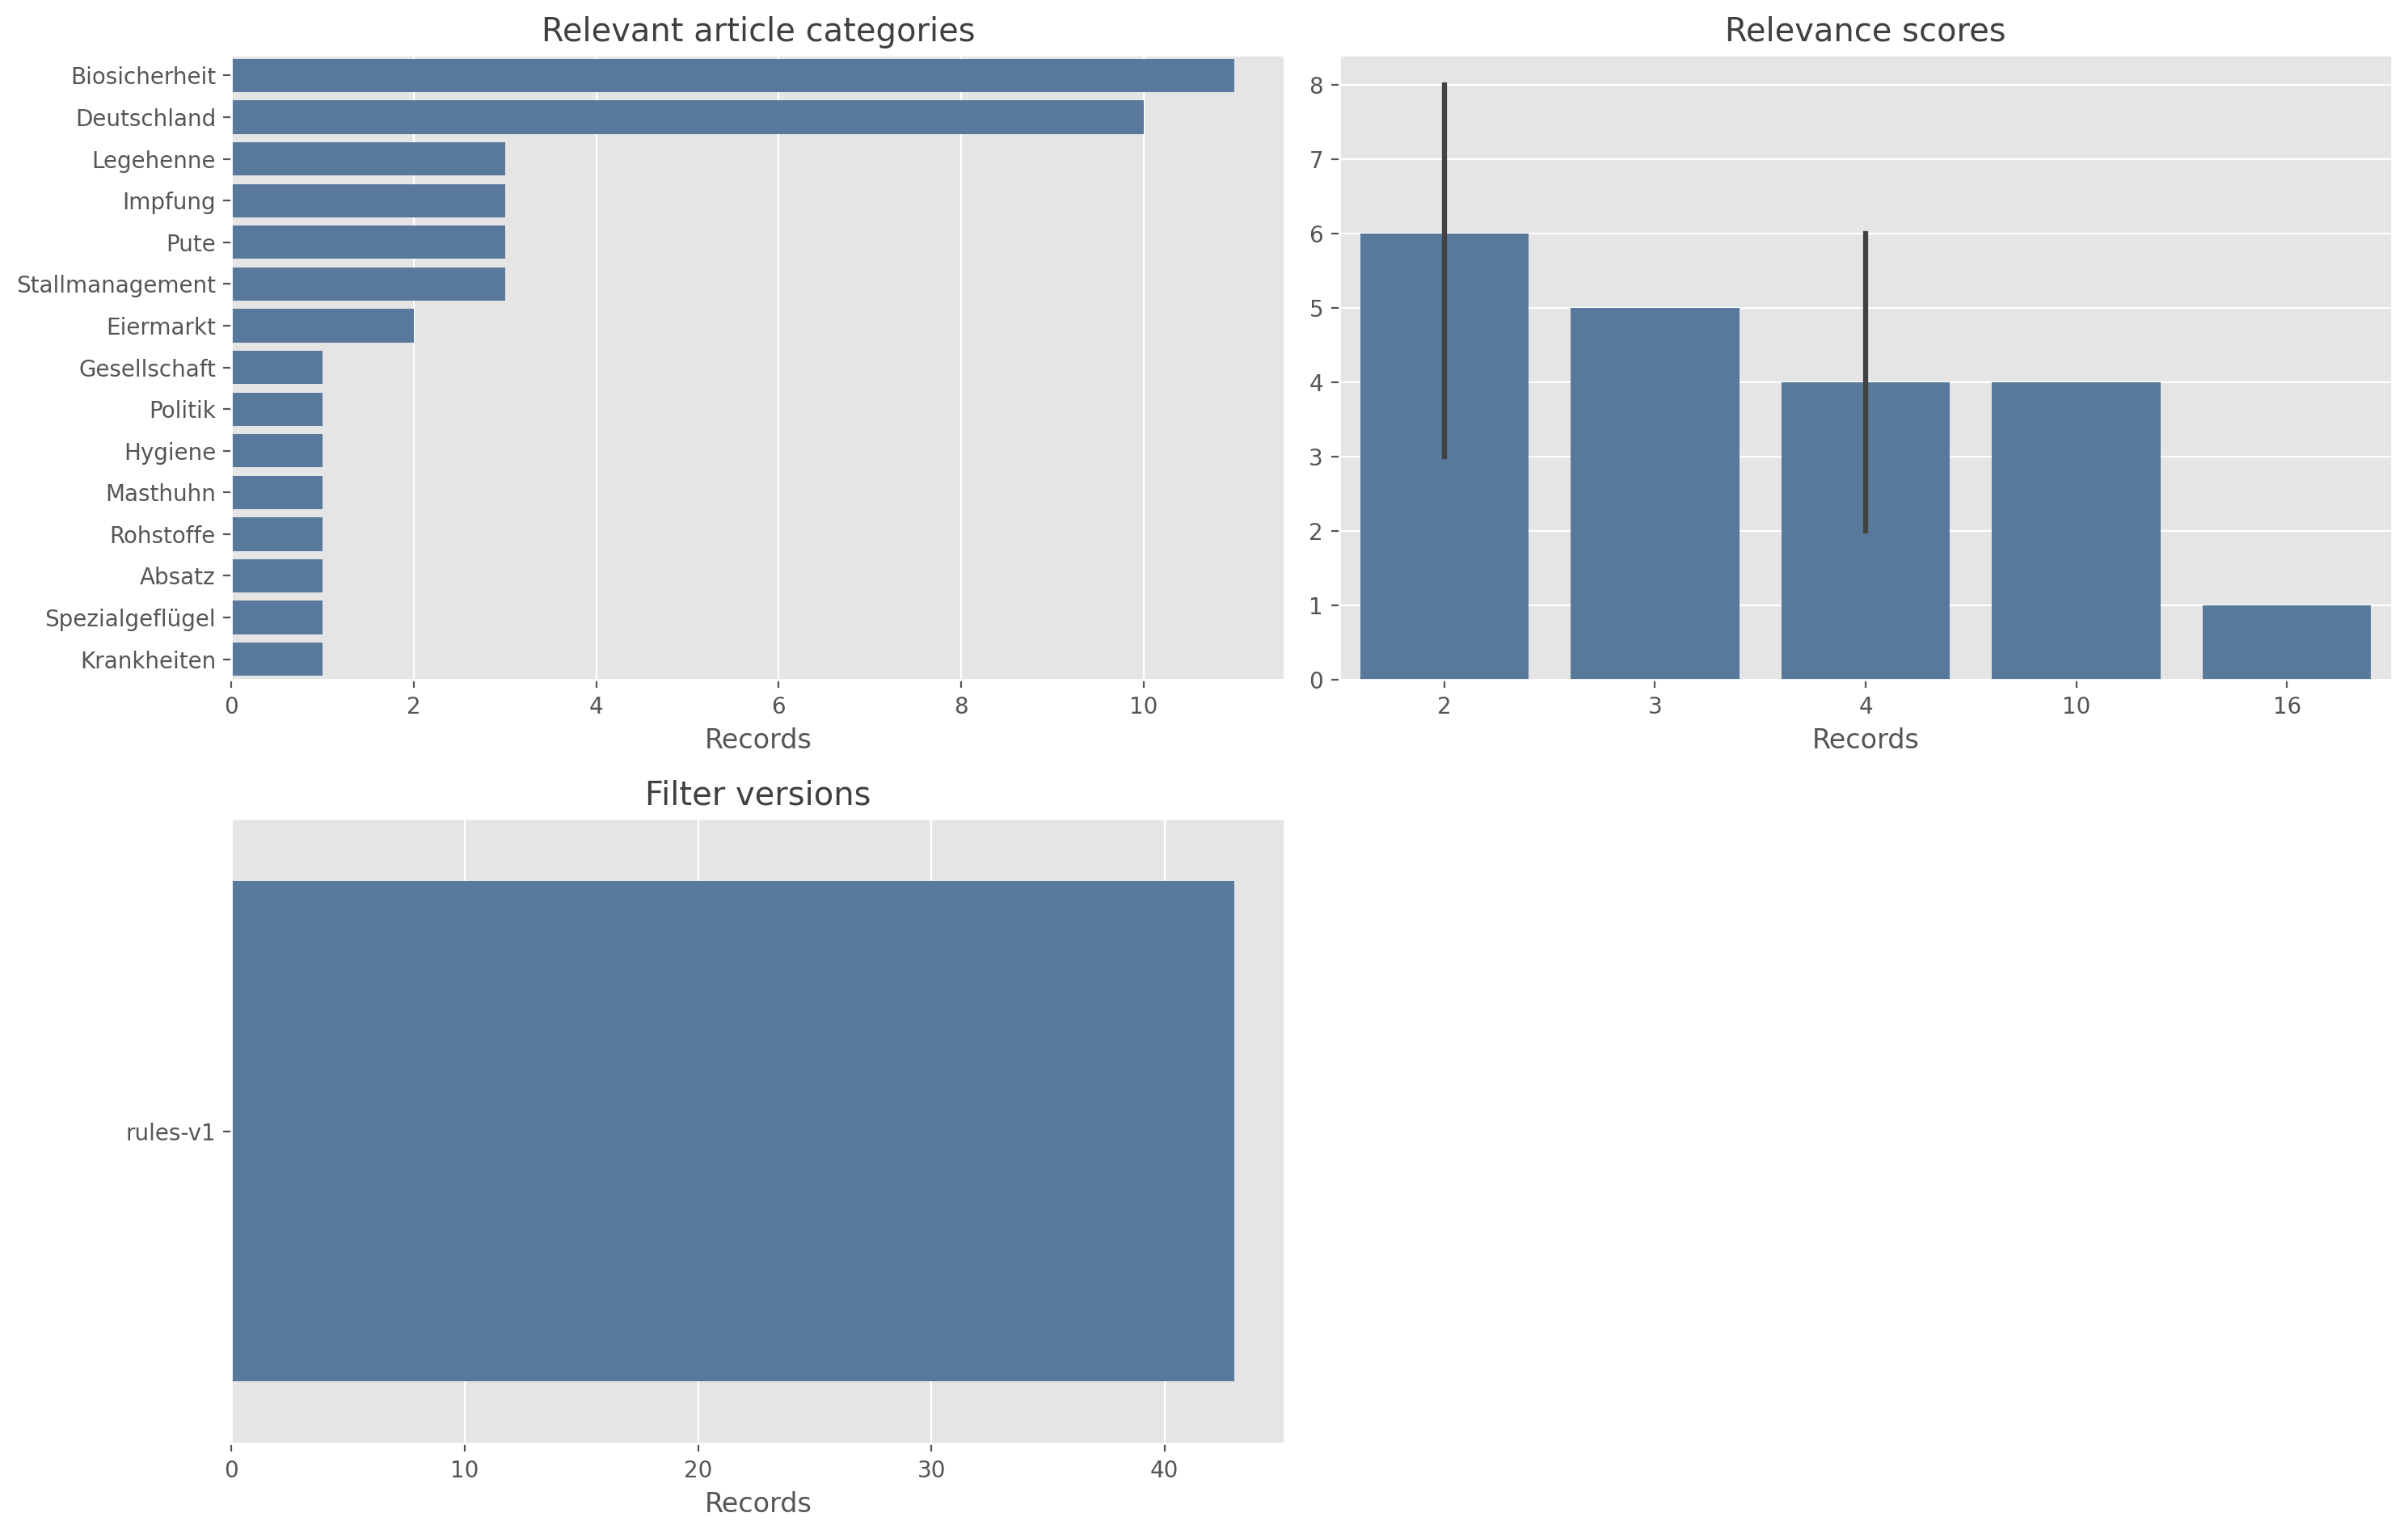

In [16]:
if disease_articles.empty:
    print("No disease_articles.jsonl rows loaded.")
else:
    display(schema_summary(disease_articles).head(50))
    plot_top_counts(
        disease_articles,
        [
            ("article.category", 15, "Relevant article categories"),
            ("relevance.score", 12, "Relevance scores"),
            ("relevance.filter_version", 10, "Filter versions"),
        ],
    )

,matched_term,articles
0,Geflügelpest,29
1,Vogelgrippe,28
2,Biosicherheit,22
3,Tierseuche,18
4,Ausbruch,12
5,Keulung,6
6,H5N1,6
7,Aviäre Influenza,6
8,HPAI,4
9,Newcastle,3


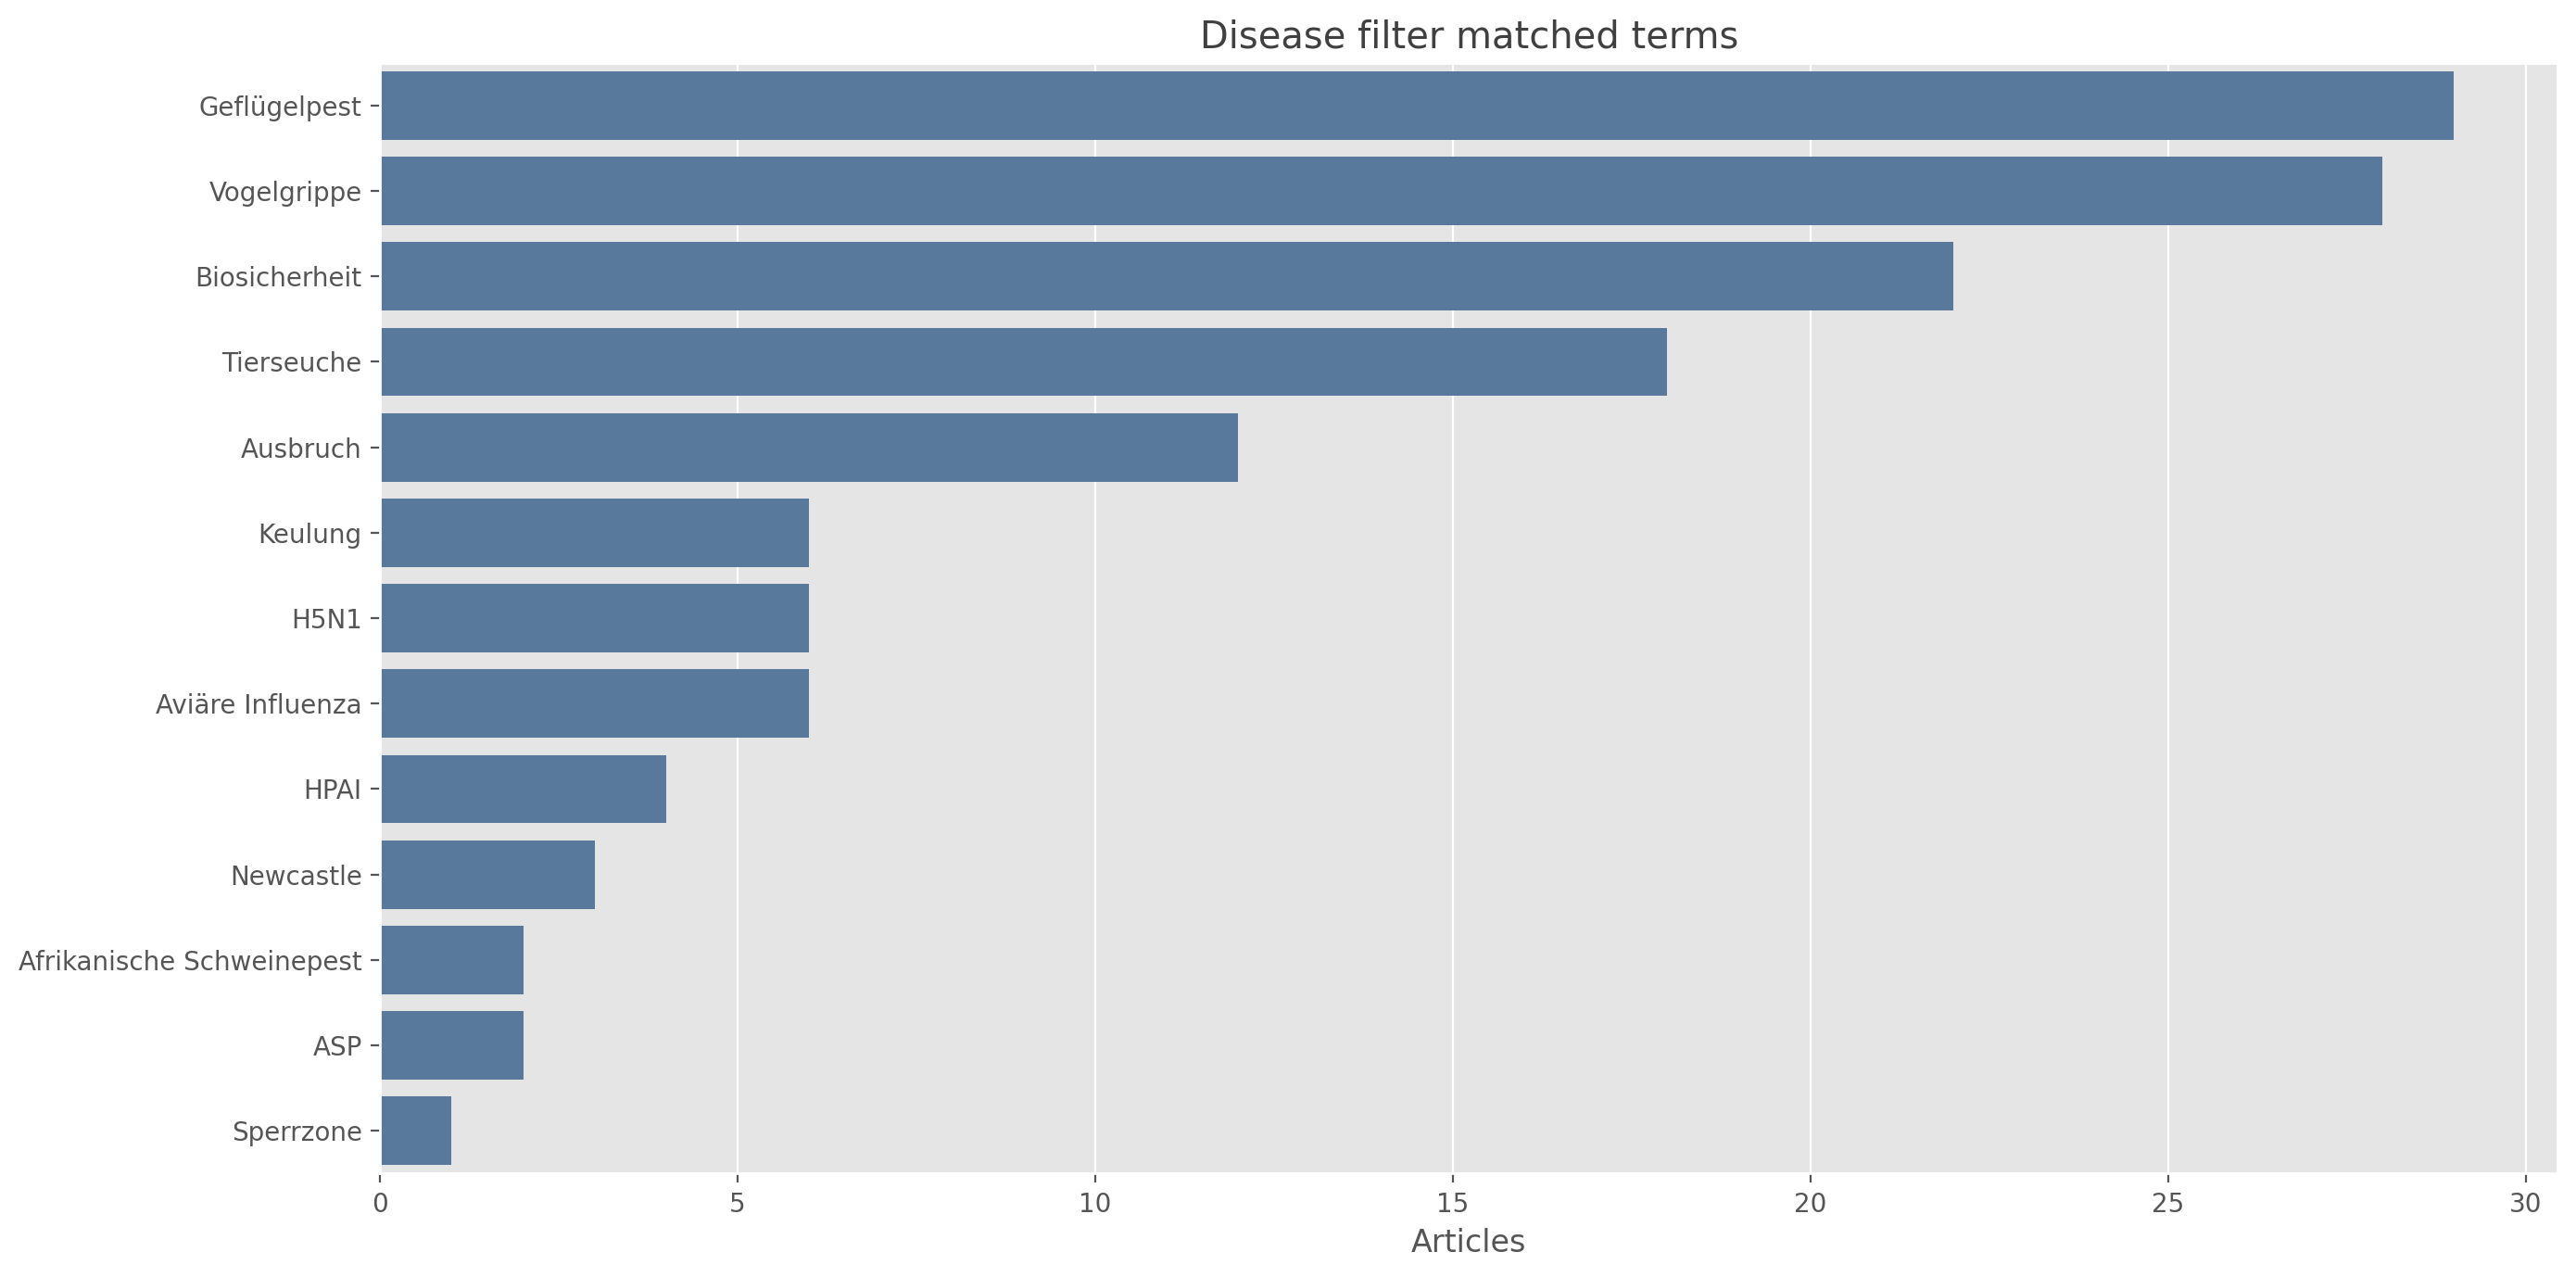

In [17]:
if not disease_articles.empty and "relevance.matched_terms" in disease_articles.columns:
    matched_term_counts = Counter(
        str(value).strip()
        for value in flatten_list_values(disease_articles["relevance.matched_terms"])
        if str(value).strip()
    )
    terms = pd.DataFrame(
        matched_term_counts.most_common(), columns=["matched_term", "articles"]
    )
    display(terms.head(40))
    if not terms.empty:
        axis = sns.barplot(
            data=terms.head(25), y="matched_term", x="articles", color="#4C78A8"
        )
        axis.set_title("Disease filter matched terms")
        axis.set_xlabel("Articles")
        axis.set_ylabel("")
        plt.tight_layout()

In [18]:
if not parse_errors.empty:
    display(parse_errors.head(20))
else:
    print("No parser failures recorded in parse_errors.jsonl.")

No parser failures recorded in parse_errors.jsonl.


## Disease Report QA


In [19]:
disease_reports, disease_report_jsonl_errors = read_jsonl(
    SOURCE_DIR / EXPECTED_JSONL["disease_reports"]
)
disease_reports = parse_datetime_columns(
    disease_reports,
    [
        "source_publication_date",
        "source_retrieved_at",
        "confirmation_date",
        "result_date",
    ],
)

print(
    f"Loaded {len(disease_reports):,} disease reports "
    f"with {len(disease_reports.columns):,} columns."
)
display(disease_reports.head())

Loaded 43 disease reports with 65 columns.


,administrative_division_level_1,administrative_division_level_2,administrative_division_level_3,approximate_location,cases,clinical_signs,confirmation_date,consequences,content_hash,control_measures,country_concept_id,country_or_territory,dead,diagnostic_tests,disease_concept_id,disease_name,disease_type,disease_type_concept_id,end_date,epidemiological_unit,evidence_snippets,extraction_confidence,extraction_method,extraction_status,extraction_version,fulltext,has_consequences,is_in_europe,killed,latitude,location,longitude,necropsy,prevention_measures,production_type,raw_html_path,raw_relevance_evidence,raw_severity_evidence,reach_level,reach_rationale,relevance_level,relevance_rationale,report_id,research_references,result_date,result_type,severity_level,severity_rationale,situation_key,situation_month,slaughtered,source_document_id,source_document_title,source_id,source_link,source_name,source_publication_date,source_retrieved_at,species,status,susceptible,suspicion_start_date,test_name,vaccinated,wildlife_type
0,None,None,None,None,None,None,NaT,# 100.000 Legehennen wegen Newcastle-Krankheit gekeult **Nach dem Nachweis der Newcastle-Krankheit auf einem großen Legehennenbetrieb i...,525a0de4581c7f69912f7b7166af6862d887aa4de09a6acef4bb47e4bb5328b3,[Keulung],NaN,NaN,None,None,newcastle-disease,Newcastle Disease,NaN,NaN,None,None,"[{'locator': 'char[233:425]', 'matched_terms': ['Geflügelpest'], 'snippet_id': 'snippet:7b7b6b15aa7c', 'source_link': 'https://www.geflu...",high,rules,candidate,rules-v1,# 100.000 Legehennen wegen Newcastle-Krankheit gekeult\n\n**Nach dem Nachweis der Newcastle-Krankheit auf einem großen Legehennenbetrieb...,True,None,None,None,None,None,None,"[{'prevention_type': 'Keulung', 'raw_evidence': 'keulen', 'text': '100.000 Legehennen wegen Newcastle-Krankheit gekeult Nach dem Ausbruc...",None,/Volumes/1TB Home SSD/GitHub/_ GitHub generell/GovTech-Tierseuchen/data/unstructured/gefluegelnews/raw_html/100000-legehennen-wegen-newc...,iebe werden kontrolliert. Newcastle-Krankheit Landkreis Erding 100.000 Legehennen Keulung Geflügelpest APMV-1 Schutzgebiet Überwachungsz...,None,None,None,high,None,gefluegelnews:100000-legehennen-wegen-newcastle-krankheit-gekeult,[],NaT,None,None,None,NaN,2026-03,None,source_document:gefluegelnews:100000-legehennen-wegen-newcastle-krankheit-gekeult,100.000 Legehennen wegen Newcastle-Krankheit gekeult,gefluegelnews,https://www.gefluegelnews.de/article/100000-legehennen-wegen-newcastle-krankheit-gekeult,Gefluegelnews,2026-03-03 00:00:00+00:00,2026-05-28 17:54:18.291174+00:00,None,None,None,None,None,None,None
1,None,None,None,None,None,None,NaT,"Entwickelt wurde sie von der ZKHL (Zentrale Koordination Handel-Landwirtschaft), zu der Vertreter der Landwirtschaft und des Lebensmitte...",ffa84d06359f702065c377e97c829c9bfb8301a7c70e86a1138e13143bd96c4b,[Handel],country-deutschland,Deutschland,None,None,hpai,HPAI,NaN,NaN,None,None,"[{'locator': 'char[468:659]', 'matched_terms': ['Vogelgrippe'], 'snippet_id': 'snippet:64ea07b36c16', 'source_link': 'https://www.geflue...",medium,rules,candidate,rules-v1,# 12. Osnabrücker Geflügelsymposium: Richtungsweisend\n\n**Die Stimmung war gut auf dem Osnabrücker Geflügelsymposium. Die Nachfrage läu...,True,True,None,None,None,None,None,"[{'prevention_type': 'Handel', 'raw_evidence': 'Handel', 'text': 'Entwickelt wurde sie von der ZKHL (Zentrale Koordination Handel-Landwi...",None,/Volumes/1TB Home SSD/GitHub/_ GitHub generell/GovTech-Tierseuchen/data/unstructured/gefluegelnews/raw_html/12-osnabrucker-geflugelsympo...,lügelsymposium FLI Tierwohl 5xD Eier Geflügelfleisch Tierwohl Geflügelpest Nachhaltigkeit Vogelgrippe ZKHL Aldi Nord Aldi Süd Edeka Kauf...,None,None,None,medium,None,gefluegelnews:12-osnabrucker-geflugelsymposium-richtungsweisend,[],NaT,None,None,None,hpai|deutschland|2025-02,2025-02,None,source_document:gefluegelnews:12-osnabrucker-geflugelsymposium-richtungsweisend,12. Osnabrücker Geflügelsymposium: Richtungsweisend,gefluegelnews,htt

,dtype,missing,missing_pct,n_unique
administrative_division_level_1,object,43,100.0,0
administrative_division_level_2,object,43,100.0,0
administrative_division_level_3,object,43,100.0,0
approximate_location,object,43,100.0,0
cases,object,43,100.0,0
clinical_signs,object,43,100.0,0
confirmation_date,"datetime64[s, UTC]",43,100.0,0
dead,object,43,100.0,0
diagnostic_tests,object,43,100.0,0
end_date,object,43,100.0,0


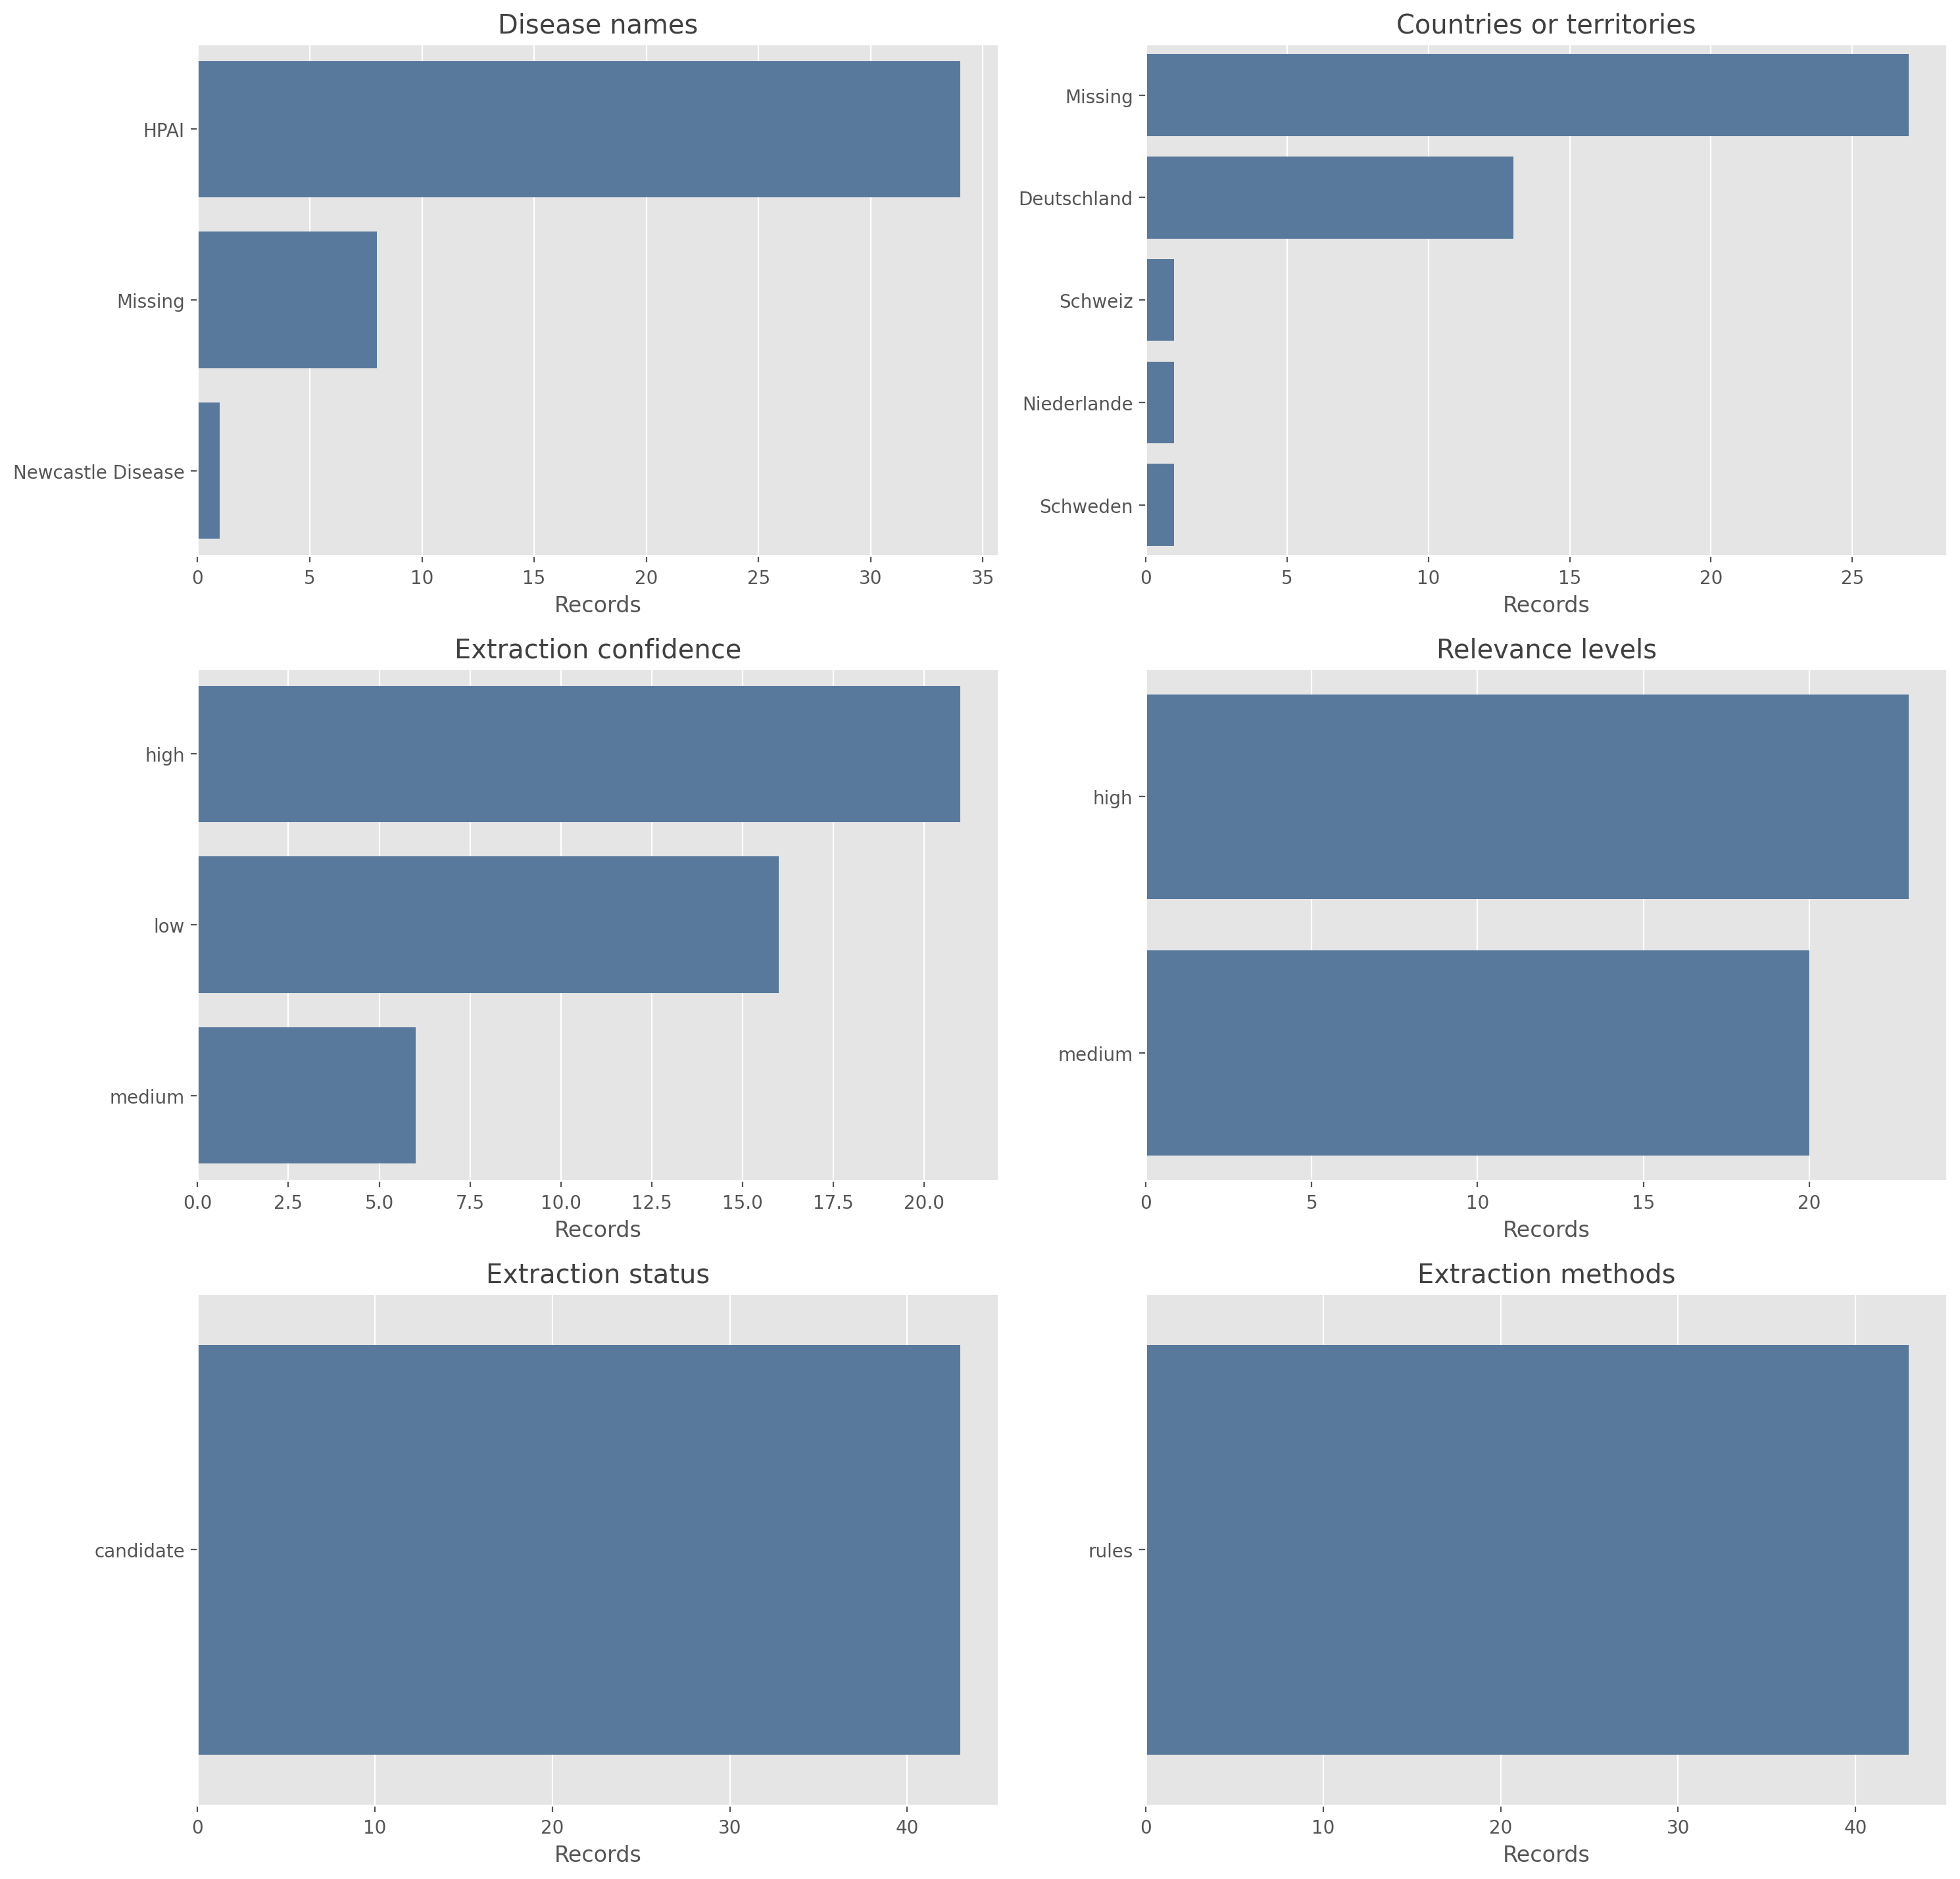

In [19]:
if disease_reports.empty:
    print("No disease_reports.jsonl rows loaded.")
else:
    display(schema_summary(disease_reports).head(80))
    plot_top_counts(
        disease_reports,
        [
            ("disease_name", 15, "Disease names"),
            ("country_or_territory", 15, "Countries or territories"),
            ("extraction_confidence", 10, "Extraction confidence"),
            ("relevance_level", 10, "Relevance levels"),
            ("extraction_status", 10, "Extraction status"),
            ("extraction_method", 10, "Extraction methods"),
        ],
    )

In [20]:
important_report_fields = [
    "report_id",
    "source_link",
    "source_publication_date",
    "disease_name",
    "country_or_territory",
    "situation_month",
    "situation_key",
    "extraction_confidence",
    "raw_relevance_evidence",
    "evidence_snippets",
]

if not disease_reports.empty:
    available_fields = [
        field for field in important_report_fields if field in disease_reports.columns
    ]
    missingness = (
        disease_reports[available_fields]
        .isna()
        .mean()
        .mul(100)
        .round(1)
        .rename("missing_pct")
        .reset_index()
        .rename(columns={"index": "field"})
        .sort_values("missing_pct", ascending=False)
    )
    display(missingness)

    mostly_missing = missingness[missingness["missing_pct"] >= 80]
    display(mostly_missing)

,field,missing_pct
6,situation_key,67.4
4,country_or_territory,62.8
3,disease_name,18.6
0,report_id,0.0
1,source_link,0.0
2,source_publication_date,0.0
5,situation_month,0.0
7,extraction_confidence,0.0
8,raw_relevance_evidence,0.0
9,evidence_snippets,0.0


,field,missing_pct


,column,min_items,median_items,max_items,zero_item_rows
0,evidence_snippets,1,3.0,5,0
1,control_measures,0,1.0,6,14
2,prevention_measures,0,1.0,6,14
3,research_references,0,0.0,0,43


,situation_month,records
0,2025-03,3
1,2022-10,3
2,2026-02,3
3,2023-02,3
4,2025-02,2
5,2026-05,2
6,2025-10,2
7,2024-01,2
8,2022-08,2
9,2026-03,1


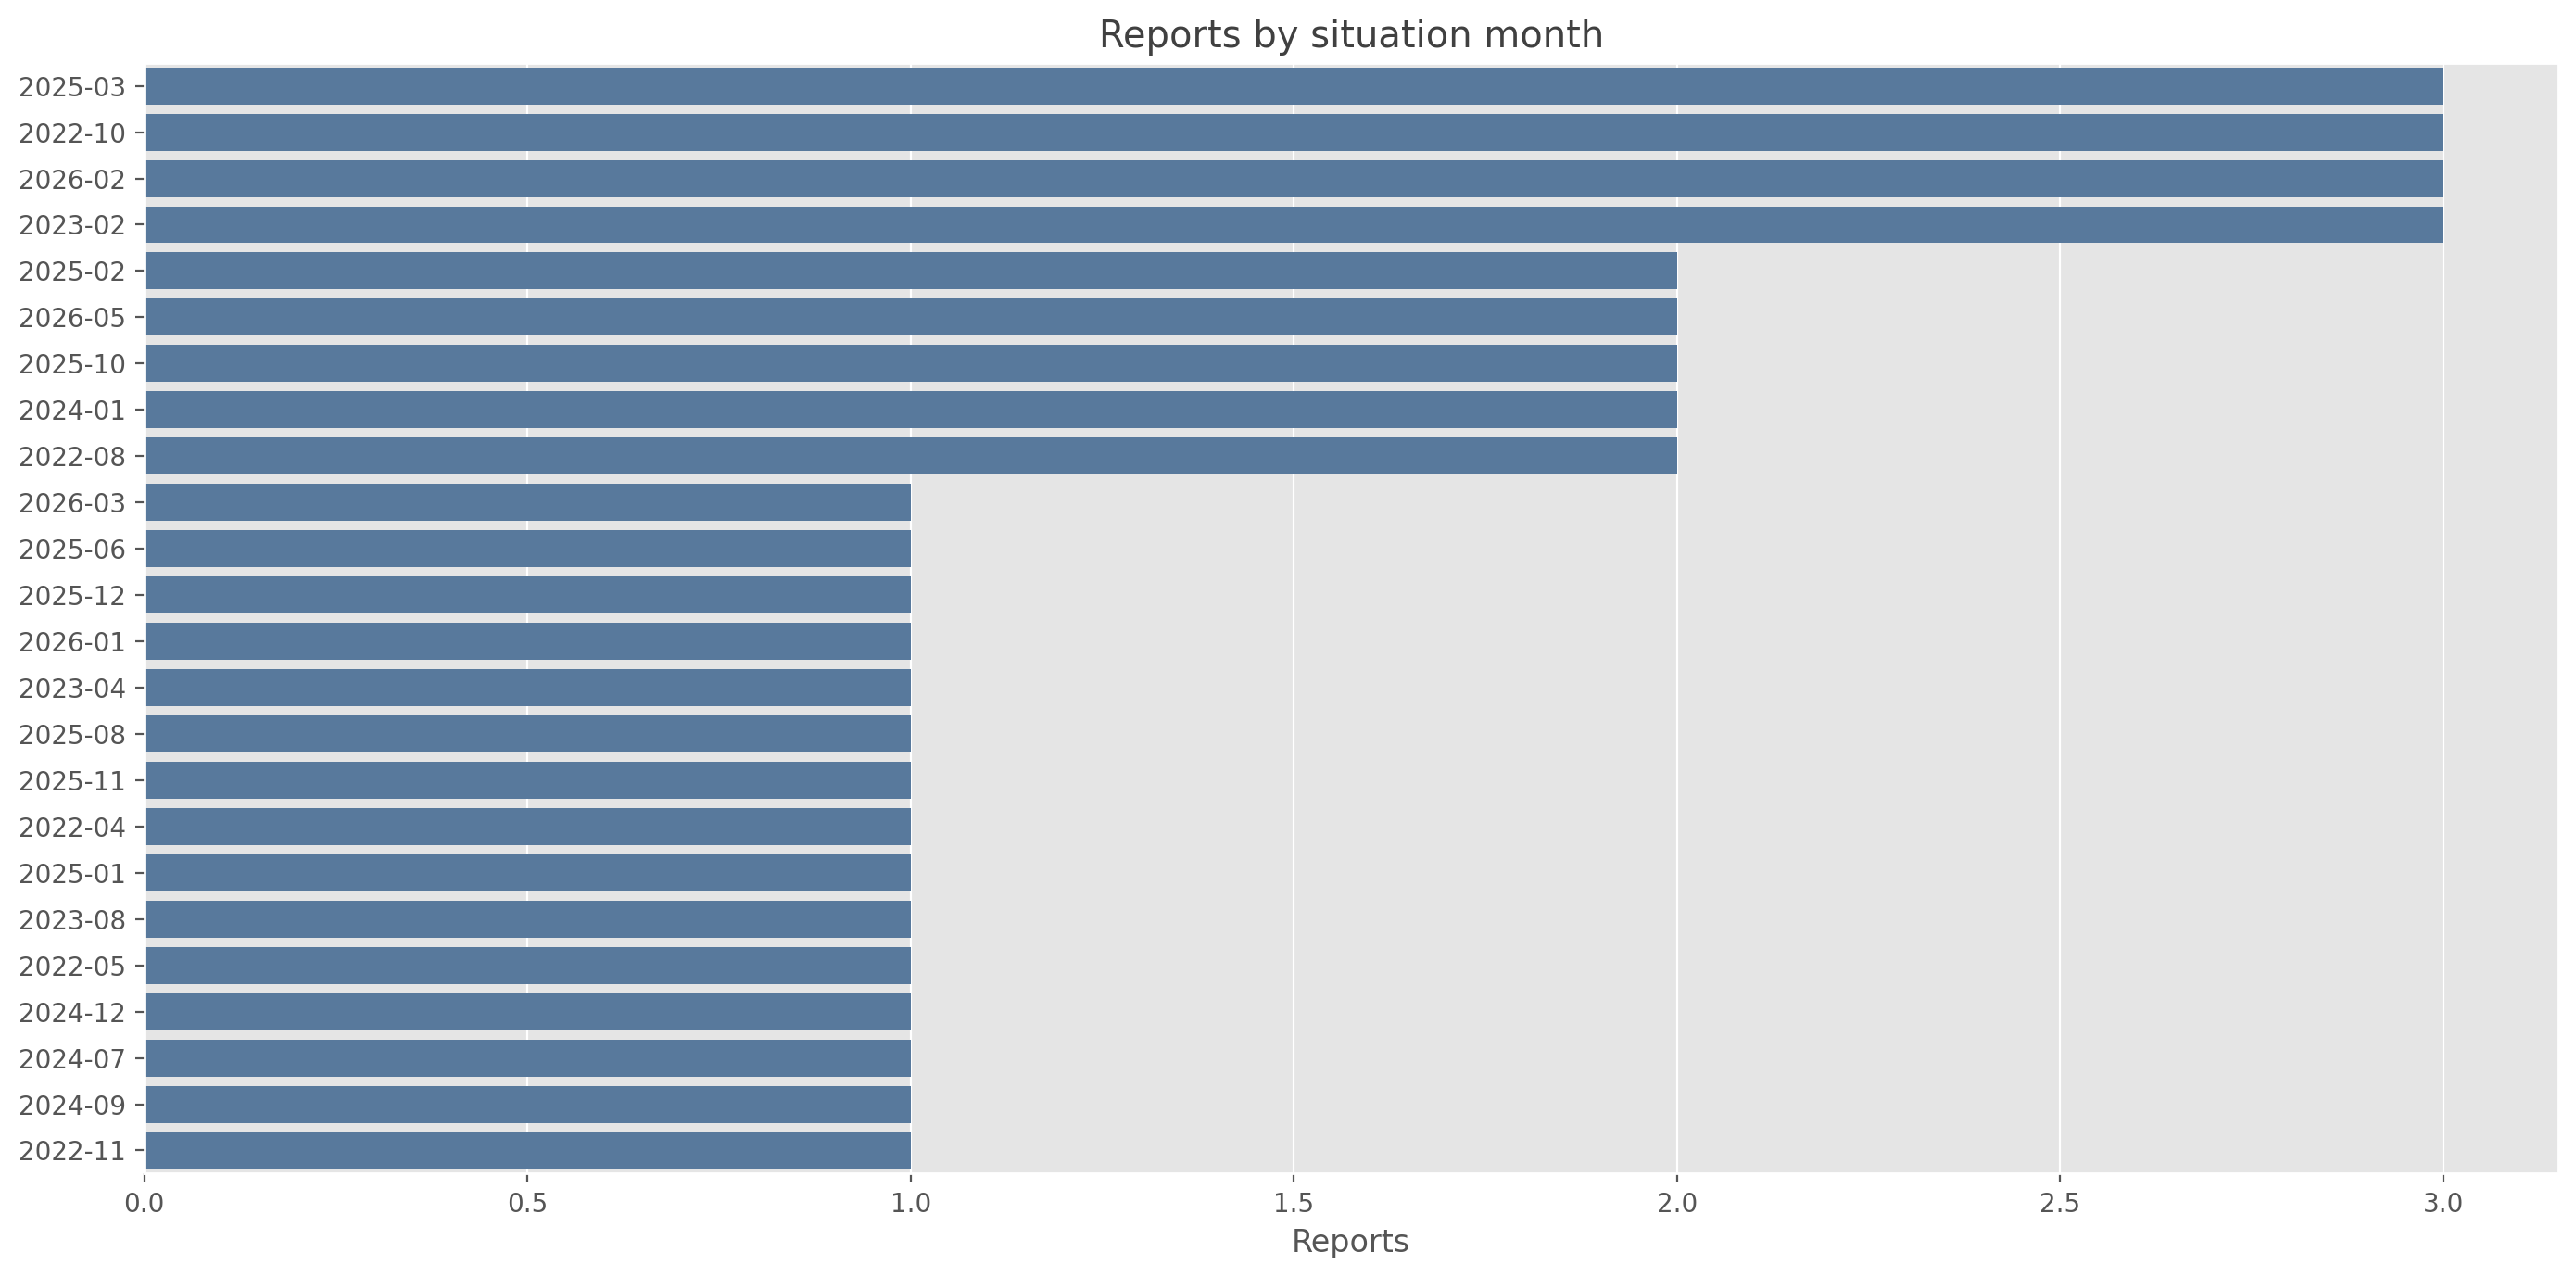

In [21]:
if not disease_reports.empty:
    list_metrics = []
    for column in [
        "evidence_snippets",
        "control_measures",
        "prevention_measures",
        "research_references",
    ]:
        if column in disease_reports.columns:
            lengths = disease_reports[column].map(list_length)
            list_metrics.append(
                {
                    "column": column,
                    "min_items": lengths.min(),
                    "median_items": lengths.median(),
                    "max_items": lengths.max(),
                    "zero_item_rows": int((lengths == 0).sum()),
                }
            )
    display(pd.DataFrame(list_metrics))

    if "situation_month" in disease_reports.columns:
        situation_months = top_counts(disease_reports, "situation_month", n=30)
        display(situation_months)
        axis = sns.barplot(
            data=situation_months.head(24),
            y="situation_month",
            x="records",
            color="#4C78A8",
        )
        axis.set_title("Reports by situation month")
        axis.set_xlabel("Reports")
        axis.set_ylabel("")
        plt.tight_layout()

In [22]:
if not disease_reports.empty:
    numeric_columns = [
        column
        for column in [
            "cases",
            "dead",
            "killed",
            "slaughtered",
            "susceptible",
            "vaccinated",
            "latitude",
            "longitude",
        ]
        if column in disease_reports.columns
    ]
    if numeric_columns:
        display(disease_reports[numeric_columns].describe(include="all"))

    sample_columns = [
        column
        for column in [
            "report_id",
            "source_publication_date",
            "disease_name",
            "country_or_territory",
            "extraction_confidence",
            "relevance_level",
            "source_document_title",
            "raw_relevance_evidence",
        ]
        if column in disease_reports.columns
    ]
    display(disease_reports[sample_columns].head(25))

,cases,dead,killed,slaughtered,susceptible,vaccinated,latitude,longitude
count,0,0,0,0,0,0,0,0
unique,0,0,0,0,0,0,0,0
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,report_id,source_publication_date,disease_name,country_or_territory,extraction_confidence,relevance_level,source_document_title,raw_relevance_evidence
0,gefluegelnews:100000-legehennen-wegen-newcastle-krankheit-gekeult,2026-03-03 00:00:00+00:00,Newcastle Disease,NaN,high,high,100.000 Legehennen wegen Newcastle-Krankheit gekeult,iebe werden kontrolliert. Newcastle-Krankheit Landkreis Erding 100.000 Legehennen Keulung Geflügelpest APMV-1 Schutzgebiet Überwachungsz...
1,gefluegelnews:12-osnabrucker-geflugelsymposium-richtungsweisend,2025-02-05 00:00:00+00:00,HPAI,Deutschland,medium,medium,12. Osnabrücker Geflügelsymposium: Richtungsweisend,lügelsymposium FLI Tierwohl 5xD Eier Geflügelfleisch Tierwohl Geflügelpest Nachhaltigkeit Vogelgrippe ZKHL Aldi Nord Aldi Süd Edeka Kauf...
2,gefluegelnews:13-osnabrucker-geflugelsymposium-diskussionen-um-impfung-und-keulung,2026-05-26 00:00:00+00:00,HPAI,Deutschland,high,high,13. Osnabrücker Geflügelsymposium: Diskussionen um Impfung und Keulung,keulungen noch zeitgemäß sind. Geflügelpest Newcastle Disease Geflügelsymposium Osnabrück HPAI Vogelgrippe Massenkeulung Biosicherheit G...
3,gefluegelnews:145-ausgesetzte-mastkuken-leipziger-polizei-und-tierheim-im-rettungseinsatz,2025-03-05 00:00:00+00:00,HPAI,NaN,medium,medium,145 ausgesetzte Mastküken: Leipziger Polizei und Tierheim im Rettungseinsatz,tküken. Leipzig Schkeuditz Tierheim Tierheim Leipzig Polizei Polizei Leipzig Geflügelpest Vogelgrippe Landkreis Leipzig Gesellschaft # 1...
4,gefluegelnews:36-millionen-euro-mehr-fur-die-tierseuchenkasse-sind-ein-foulspiel-gegen-geflugelhalter,2022-10-06 00:00:00+00:00,HPAI,NaN,high,high,"„3,6 Millionen Euro mehr für die Tierseuchenkasse sind ein Foulspiel gegen Geflügelhalter""","23 von den Tierhaltern zusätzlich aufgebracht werden sollen. Otte Kinast Tierseuchenkasse Vogelgrippe Finanzierung Politik # „3,6 Millio..."
5,gefluegelnews:426-eier-pro-henne-in-90-wochen-schottische-neueinsteiger-meistern-legehennenhaltung,2025-06-03 00:00:00+00:00,NaN,NaN,low,medium,426 Eier pro Henne in 90 Wochen: Schottische Neueinsteiger meistern Legehennenhaltung,rtspaar erzielt mit 32.000 Hennen 426 Eier pro Tier – dank klarem Management und strenger Biosicherheit. Landwirtschaft Landwirt Landwir...
6,gefluegelnews:8600-tiere-gekeult-wie-die-vogelgrippe-einen-hof-in-brandenburg-an-den-rand-der-belastbarkeit-brachte,2026-02-08 00:00:00+00:00,HPAI,NaN,high,high,8600 Tiere gekeult: Wie die Vogelgrippe einen Hof in Brandenburg an den Rand der Belastbarkeit brachte,"Bereich, Entschädigung unklar – dennoch startet der Betrieb neu. Vogelgrippe Geflügelpest H5N1 Brandenburg Spargelhof Kremmen Malte Voig..."
7,gefluegelnews:abhangigkeit-von-china-gefahrdet-futtermittelversorgung-dvt-fordert-politisches-handeln,2025-12-10 00:00:00+00:00,NaN,Schweiz,low,medium,Abhängigkeit von China gefährdet Futtermittelversorgung: DVT fordert politisches Handeln,önnte jedoch zum Jahresende an Dynamik verlieren. Der Verband erwartet aufgrund aktueller Tierseuchen ein schwächeres Geschäft im vierte...
8,gefluegelnews:ablehnende-haltung-zur-impfung-gegen-vogelgrippe-kippt-weltweit,2023-02-23 00:00:00+00:00,HPAI,NaN,high,high,Ablehnende Haltung zur Impfung gegen Vogelgrippe kippt weltweit,"Ablehnende Haltung zur Impfung gegen Vogelgrippe kippt weltweit Angesichts der Vogelgrippe (Aviäre Influenza, AI), die weltweit Millione..."
9,gefluegelnews:achtung-fehlender-biosicherheitsplan-kann-richtig-viel-geld-kosten,2025-10-17 00:00:00+00:00,HPAI,NaN,high,high,Achtung: Fehlender Biosicherheitsplan kann richtig viel Geld kosten!,rheits-Managementplan Geflügelberatung Tierarzt Entschädigungsleistungen Tierseuchenkasse Vogelgrippe Niedersachsen Geflügelseuche EU-Ri...


## Embedding and Enrichment QA


In [23]:
if disease_reports_embeddings.empty:
    print("No disease_reports_embeddings.jsonl rows loaded.")
else:
    display(schema_summary(disease_reports_embeddings).head(80))

    comparison = {
        "disease_reports_rows": len(disease_reports),
        "embedding_rows": len(disease_reports_embeddings),
    }
    if (
        "report_id" in disease_reports.columns
        and "report_id" in disease_reports_embeddings.columns
    ):
        report_ids = set(disease_reports["report_id"].dropna())
        embedding_report_ids = set(disease_reports_embeddings["report_id"].dropna())
        comparison.update(
            {
                "reports_without_embedding_row": len(report_ids - embedding_report_ids),
                "embedding_rows_without_report": len(embedding_report_ids - report_ids),
                "duplicate_embedding_report_ids": int(
                    disease_reports_embeddings["report_id"].dropna().duplicated().sum()
                ),
            }
        )
    display(pd.DataFrame([comparison]).T.rename(columns={0: "value"}))

,dtype,missing,missing_pct,n_unique
administrative_division_level_1,object,4,100.0,0
administrative_division_level_2,object,4,100.0,0
administrative_division_level_3,object,4,100.0,0
approximate_location,object,4,100.0,0
cases,object,4,100.0,0
clinical_signs,object,4,100.0,0
confirmation_date,"datetime64[s, UTC]",4,100.0,0
dead,object,4,100.0,0
diagnostic_tests,object,4,100.0,0
disease_type,object,4,100.0,0


,value
disease_reports_rows,43
embedding_rows,4
reports_without_embedding_row,39
embedding_rows_without_report,0
duplicate_embedding_report_ids,0


In [24]:
embedding_candidate_columns = [
    column
    for column in disease_reports_embeddings.columns
    if column.lower() in {"embedding", "embeddings", "vector", "vectors"}
    or column.lower().endswith("embedding")
    or column.lower().endswith("embeddings")
]

if disease_reports_embeddings.empty:
    pass
elif not embedding_candidate_columns:
    print("No embedding vector columns detected. Available enrichment columns:")
    display(pd.DataFrame({"column": disease_reports_embeddings.columns}))
else:
    vector_metrics = []
    for column in embedding_candidate_columns:
        lengths = disease_reports_embeddings[column].map(list_length)
        vector_metrics.append(
            {
                "column": column,
                "non_null": disease_reports_embeddings[column].notna().sum(),
                "min_dimension": lengths[lengths > 0].min()
                if (lengths > 0).any()
                else None,
                "median_dimension": lengths[lengths > 0].median()
                if (lengths > 0).any()
                else None,
                "max_dimension": lengths.max(),
                "malformed_or_missing": int((lengths == 0).sum()),
            }
        )
    display(pd.DataFrame(vector_metrics))

No embedding vector columns detected. Available enrichment columns:


,column
0,administrative_division_level_1
1,administrative_division_level_2
2,administrative_division_level_3
3,approximate_location
4,cases
5,clinical_signs
6,confirmation_date
7,consequences
8,content_hash
9,control_measures


## Records to Inspect


In [25]:
if not disease_reports.empty:
    candidate_columns = [
        "report_id",
        "source_link",
        "source_publication_date",
        "disease_name",
        "country_or_territory",
        "situation_month",
        "extraction_confidence",
        "relevance_level",
        "source_document_title",
        "raw_relevance_evidence",
    ]
    columns = [
        column for column in candidate_columns if column in disease_reports.columns
    ]
    display(
        disease_reports[columns].sample(min(10, len(disease_reports)), random_state=42)
    )
elif not disease_articles.empty:
    candidate_columns = [
        "article.title",
        "article.publication_date",
        "article.category",
        "relevance.score",
        "relevance.matched_terms",
        "article.source_link",
    ]
    columns = [
        column for column in candidate_columns if column in disease_articles.columns
    ]
    display(
        disease_articles[columns].sample(
            min(10, len(disease_articles)), random_state=42
        )
    )
elif not articles.empty:
    candidate_columns = [
        "title",
        "publication_date",
        "category",
        "source_link",
        "description",
    ]
    columns = [column for column in candidate_columns if column in articles.columns]
    display(articles[columns].sample(min(10, len(articles)), random_state=42))
else:
    print("No loaded rows available for inspection.")

,report_id,source_link,source_publication_date,disease_name,country_or_territory,situation_month,extraction_confidence,relevance_level,source_document_title,raw_relevance_evidence
37,gefluegelnews:aut-munster-mit-bollis-punkten-in-sachen-biosicherheit,https://www.gefluegelnews.de/article/aut-munster-mit-bollis-punkten-in-sachen-biosicherheit,2026-02-06 00:00:00+00:00,NaN,NaN,2026-02,low,medium,AUT Münster: Mit „Böllis“ punkten in Sachen Biosicherheit,AUT Münster: Mit „Böllis“ punkten in Sachen Biosicherheit Geflügelhalter setzen auf „Böllis“: Stroh-Strukturpellets verbessern Biosicher...
24,gefluegelnews:arbeitsgruppe-geflugel-landvolk-niedersachsen-schafft-neue-plattform,https://www.gefluegelnews.de/article/arbeitsgruppe-geflugel-landvolk-niedersachsen-schafft-neue-plattform,2025-03-18 00:00:00+00:00,HPAI,NaN,2025-03,low,medium,Arbeitsgruppe Geflügel: Landvolk Niedersachsen schafft neue Plattform,band Interessenvertretung Landwirtschaft Landwirtschaftlicher Austausch Tierhalterverband Geflügelpest Hygienemaßnahmen Geflügel Markt f...
25,gefluegelnews:asp-droht-flachenbrand-in-hessen,https://www.gefluegelnews.de/article/asp-droht-flachenbrand-in-hessen,2024-07-24 00:00:00+00:00,HPAI,NaN,2024-07,high,high,ASP: Droht Flächenbrand in Hessen?,"P: Droht Flächenbrand in Hessen? Was die Geflügelhaltung aus leidvoller Erfahrung mit der Geflügelpest kennt, droht nun auch in der Schw..."
36,gefluegelnews:australiens-regierung-zieht-durch-kafigverbot-ruckt-naher-und-bringt-geflugelhalter-auf-die-barrikaden,https://www.gefluegelnews.de/article/australiens-regierung-zieht-durch-kafigverbot-ruckt-naher-und-bringt-geflugelhalter-auf-die-barrikaden,2026-04-15 00:00:00+00:00,HPAI,NaN,2026-04,low,medium,Australiens Regierung zieht durch: Käfigverbot rückt näher und bringt Geflügelhalter auf die Barrikaden,Käfighaltung Tierwohl Geflügelhaltung Victoria Eierproduktion Käfigverbot Landwirtschaft Vogelgrippe Investitionen Tierschutzgesetz Gefl...
34,gefluegelnews:aussteller-portrait-auf-der-70-grenzland-gefluegelschau-des-rgzv-kleve,https://www.gefluegelnews.de/article/aussteller-portrait-auf-der-70-grenzland-gefluegelschau-des-rgzv-kleve,2022-10-15 00:00:00+00:00,HPAI,NaN,2022-10,low,medium,Aussteller-Portrait auf der 70. Grenzland-Geflügelschau des RGZV Kleve,"tern mit Rat zur Seite stehen. Leider war es aufgrund der Entwicklungen rund um das Thema Vogelgrippe den Niederländern nicht möglich, T..."
39,gefluegelnews:backhaus-fordert-impfung-gegen-vogelgrippe-warum-ist-das-in-deutschland-nicht-moglich,https://www.gefluegelnews.de/article/backhaus-fordert-impfung-gegen-vogelgrippe-warum-ist-das-in-deutschland-nicht-moglich,2025-10-30 00:00:00+00:00,HPAI,Deutschland,2025-10,high,high,Backhaus fordert Impfung gegen Vogelgrippe – „Warum ist das in Deutschland nicht möglich?“,t. Statt Massenkeulung sollen Ringimpfungen das Virus eindämmen. Geflügelpest Vogelgrippe H5N1 Geflügelimpfung Ringimpfung Till Backhaus...
4,gefluegelnews:36-millionen-euro-mehr-fur-die-tierseuchenkasse-sind-ein-foulspiel-gegen-geflugelhalter,https://www.gefluegelnews.de/article/36-millionen-euro-mehr-fur-die-tierseuchenkasse-sind-ein-foulspiel-gegen-geflugelhalter,2022-10-06 00:00:00+00:00,HPAI,NaN,2022-10,high,high,"„3,6 Millionen Euro mehr für die Tierseuchenkasse sind ein Foulspiel gegen Geflügelhalter""","23 von den Tierhaltern zusätzlich aufgebracht werden sollen. Otte Kinast Tierseuchenkasse Vogelgrippe Finanzierung Politik # „3,6 Millio..."
12,gefluegelnews:ai-impfdurchbruch-keine-uberraschung-fur-die-wissenschaft,https://www.gefluegelnews.de/article/ai-impfdurchbruch-keine-uberraschung-fur-die-wissenschaft,2024-01-15 00:00:00+00:00,HPAI,Deutschland,2024-01,high,high,AI-Impfdurchbruch: Keine Überraschung für die Wissenschaft,"bsoluten Schutz. Ihr Zweck ist, Infektionen und Übertragungen zu reduzieren. Geflügelpest Vogelgrippe Enten Frankreich AI Aviäre Influen..."
8,gefluegelnews:ablehnende-haltung-zur-impfung-gegen-vogelgrippe-kippt-weltweit,https://www.gefluegelnews.de/a